# Packages
---

Packages to procede with the code


In [ ]:
## Connect to Google Drive -- put the df_microstates and shared_variance datasets in there for easier processing.

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
## Import packages

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os
from pandas import core
import matplotlib.colors as mcolors
import scipy.stats
import csv
from scipy.stats import ttest_ind_from_stats, norm
import re
import matplotlib.font_manager
import matplotlib.lines as mlines # import the lines module
# from sklearn.impute import SimpleImputer
from PIL import Image



# Functions

In [ ]:
def FDR(pvalues, label="p_value"):
  """
  This function calculates the False Discovery Rate (FDR) for a set of p-values.

  Args:
      pvalues: A pandas Series containing the p-values.
      label: The name of the column in the DataFrame containing the p-values (optional).

  Returns:
      A pandas DataFrame with the original p-values and the calculated FDR values.
  """

  # Create a copy of the DataFrame to avoid modifying the original data
  if isinstance(pvalues, pd.Series):
    pvalues_df = pvalues.to_frame(name=label)
  else:
    pvalues_df = pvalues.copy()

  # Sort the DataFrame by the p-values
  pvalues_df = pvalues_df.sort_values(by=label)

  # Reset the index to avoid confusion with the original index
  pvalues_df = pvalues_df.reset_index(drop=True)

  # Calculate the FDR (and Bonferroni)
  pvalues_df['FDR'] = [None] * (len(pvalues_df))

  pvalues_df['BF'] = [None] * (len(pvalues_df))

  pvalues_df.loc[len(pvalues_df)-1, 'FDR'] = pvalues_df[label].iloc[-1]


  BH = pvalues_df[label] * len(pvalues_df) / (pvalues_df.index+1)
  BF = pvalues_df[label] * len(pvalues_df)
  pvalues_df.loc[len(pvalues_df)-1,'BF'] = min(BF[len(pvalues_df)-1],1)

  for i in reversed(range(len(pvalues_df)-1)):
    prv_BH = pvalues_df['FDR'].iloc[i+1]
    pvalues_df.loc[i,'FDR'] = min(BH[i],prv_BH)
    pvalues_df.loc[i,'BF'] = min(BF[i],1)


  return pvalues_df

# **EEG microstates on psilocybin**
---

This code is used to analyze EEG data from Psiconnect. The data were independently filtered in EEGLAB and the relevant statistics were obtained from the MICROSTATELAB plug in.


# Load data
---

First, the data is loaded. For this, download the df_microstates.csv and put it in Google Drive. Once this is done, the code below will split it in all possible subconditions which will be tested later on. Similarly, shared variance of individual microstate topographies with the average one is used in the following code block.

In [ ]:
## Loading all dataset to the code and adding the description

df = pd.read_csv('drive/MyDrive/df_microstates.csv')
df = df.drop('Unnamed: 0', axis=1)

## Preprocessing the shared variance dataset.

sharedvar = pd.read_csv('drive/MyDrive/shared_variance.csv')
sharedvar = sharedvar.drop('Unnamed: 0', axis=1)


#Prerequisites for the following analyses
---

## Question 0a: What is the variance across all the microstates?
---
This question is rather to see whether we can group all the EEG microstates into one and still talk about the same phenomenon.

In [ ]:

# Use .iloc to access every fourth row by integer position and the column by position
sharedvarA = sharedvar.iloc[::4,:]  # Select every fourth row starting from the first row (index 0) and the second column (index 1)
sharedvarB = sharedvar.iloc[1::4,:] # Select every fourth row starting from the second row (index 1) and the third column (index 2)
sharedvarC = sharedvar.iloc[2::4,:] # Select every fourth row starting from the third row (index 2) and the fourth column (index 3)
sharedvarD = sharedvar.iloc[3::4,:] # Select every fourth row starting from the fourth row (index 3) and the fifth column (index 4)


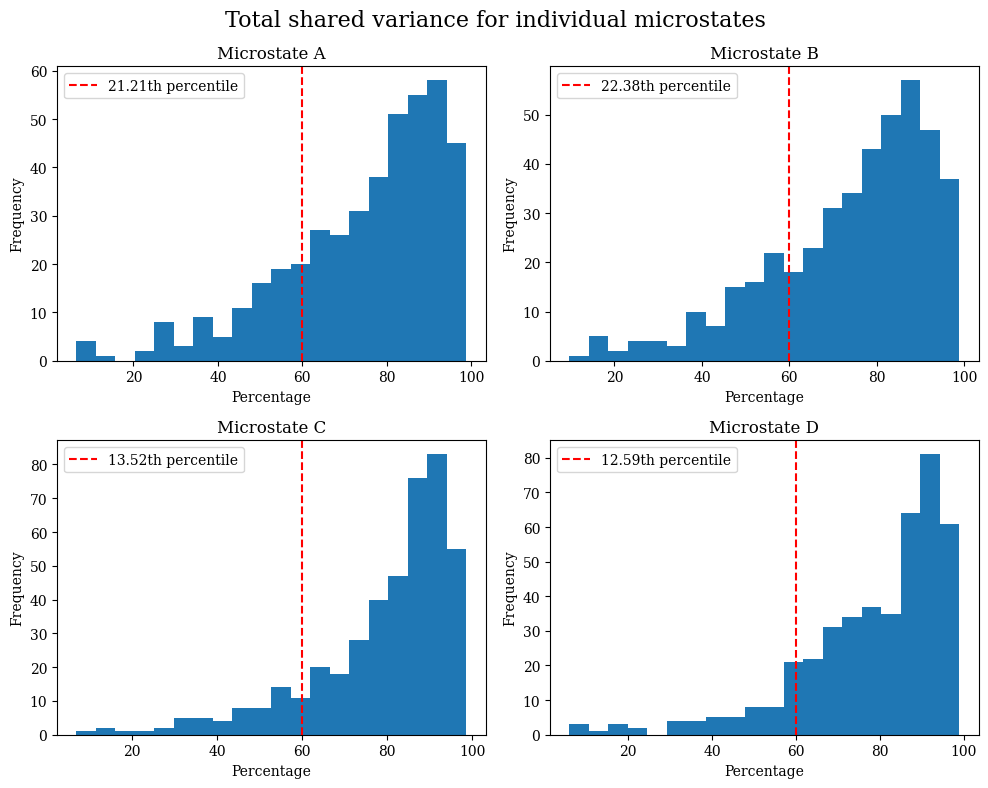

In [ ]:
## Removing all microstate data that do not share at least 60% of variance with the averaged topographies

perc_to_know = 60
values_A = sharedvarA.iloc[:, 1].values
values_B = sharedvarB.iloc[:, 2].values
values_C = sharedvarC.iloc[:, 3].values
values_D = sharedvarD.iloc[:, 4].values

percentile_A = scipy.stats.percentileofscore(values_A, perc_to_know)
percentile_B = scipy.stats.percentileofscore(values_B, perc_to_know)
percentile_C = scipy.stats.percentileofscore(values_C, perc_to_know)
percentile_D = scipy.stats.percentileofscore(values_D, perc_to_know)

plt.rcParams['font.family'] = 'serif'

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Total shared variance for individual microstates', fontsize=16)

# Plot histograms on subplots
axes[0, 0].hist(values_A, bins=20)
axes[0, 0].axvline(x=60, color='r', linestyle='--', label=f'{percentile_A:.2f}th percentile')
axes[0, 0].set_xlabel('Percentage')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Microstate A')
axes[0, 0].legend()

axes[0, 1].hist(values_B, bins=20)
axes[0, 1].axvline(x=60, color='r', linestyle='--', label=f'{percentile_B:.2f}th percentile')
axes[0, 1].set_xlabel('Percentage')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Microstate B')
axes[0, 1].legend()

axes[1, 0].hist(values_C, bins=20)
axes[1, 0].axvline(x=60, color='r', linestyle='--', label=f'{percentile_C:.2f}th percentile')
axes[1, 0].set_xlabel('Percentage')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Microstate C')
axes[1, 0].legend()

axes[1, 1].hist(values_D, bins=20)
axes[1, 1].axvline(x=60, color='r', linestyle='--', label=f'{percentile_D:.2f}th percentile')
axes[1, 1].set_xlabel('Percentage')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Microstate D')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

fig.savefig('shared_var.png')

In [ ]:
# Get labels from all DataFrames for values in bottom perc_threshold
bottom_labels_A = sharedvarA.loc[values_A <= perc_to_know, 'Row'].tolist()
bottom_labels_B = sharedvarB.loc[values_B <= perc_to_know, 'Row'].tolist()
bottom_labels_C = sharedvarC.loc[values_C <= perc_to_know, 'Row'].tolist()
bottom_labels_D = sharedvarD.loc[values_D <= perc_to_know, 'Row'].tolist()

# Combine all labels and remove duplicates
all_labels = bottom_labels_A + bottom_labels_B + bottom_labels_C + bottom_labels_D

# Count occurrences of specific words
word_counts = {
    'video': 0,
    'restingstate': 0,
    'music': 0,
    'meditation': 0,
    'ctrl': 0,
    'psi': 0
}

for label in all_labels:
    for word in word_counts.keys():
        if word in label.lower():  # Convert to lowercase for case-insensitive matching
            word_counts[word] += 1

# Count occurrences of sub2XX and sub0XX patterns
sub2xx_count = 0
sub0xx_count = 0
for label in all_labels:
    if 'sub2' in label:
        sub2xx_count += 1
    elif 'sub0' in label:
        sub0xx_count += 1

# Print results
print("Word counts:")
for word, count in word_counts.items():
    print(f"{word}: {count}")

print("\nPattern counts:")
print(f"meditators: {sub2xx_count}")
print(f"non meditators: {sub0xx_count}")

Word counts:
video: 81
restingstate: 68
music: 79
meditation: 71
ctrl: 146
psi: 153

Pattern counts:
meditators: 155
non meditators: 144


In [ ]:
## This algorithm replaces those microstates data with variance lower than 60% to NaN

for label in all_labels:
    topomap = label.split(' ')[0]
    label_in_brackets = label[label.find("(")+1:label.find(")")]
    mask = df['Dataset'].str.contains(label_in_brackets, na=False)

    # Columns with topomap to set to NaN
    columns_to_nan = [col for col in df.columns[5:-1] if ('_' + topomap) in col]
    for col in columns_to_nan:
        df.loc[mask, col] = df.loc[mask, col].apply(lambda x: np.nan if pd.notnull(x) else x)

    # Columns with 'All' to set to NaN
    columns_all_to_nan = [col for col in df.columns if 'All' in col]
    for col in columns_all_to_nan:
        df.loc[mask, col] = df.loc[mask, col].apply(lambda x: np.nan if pd.notnull(x) else x)



# Split datasets and provide descriptive statistics

Questions: How many datasets remained for subconditions, sessions, and groups?


In [ ]:
conditions = ['video', 'restingstate', 'meditation','music']
groups = ['non meditator','meditator']
measurement_types = ['ctrl', 'psi']

for measurement_type in measurement_types:
    print(f"Counts for {measurement_type}:")
    df_subset = df[df['psi/ctrl'] == measurement_type]
    for condition in conditions:
        for group in groups:
            count = df_subset[(df_subset['Condition'] == condition) & (df_subset['Group'] == group)].shape[0]
            print(f"  {condition}, {group}: {count}")

Counts for ctrl:
  video, non meditator: 24
  video, meditator: 29
  restingstate, non meditator: 28
  restingstate, meditator: 31
  meditation, non meditator: 29
  meditation, meditator: 31
  music, non meditator: 29
  music, meditator: 31
Counts for psi:
  video, non meditator: 17
  video, meditator: 22
  restingstate, non meditator: 25
  restingstate, meditator: 27
  meditation, non meditator: 26
  meditation, meditator: 28
  music, non meditator: 24
  music, meditator: 28


In [ ]:
conditions = ['video', 'restingstate', 'meditation','music']
groups = ['non meditator','meditator']

shared_counts = 0
for condition in conditions:
    for group in groups:
        ctrl_subjects = df[(df['Condition'] == condition) & (df['Group'] == group) & (df['psi/ctrl'] == 'ctrl')]['Subject'].unique()
        psi_subjects = df[(df['Condition'] == condition) & (df['Group'] == group) & (df['psi/ctrl'] == 'psi')]['Subject'].unique()
        shared_subjects = set(ctrl_subjects).intersection(psi_subjects)
        shared_counts += len(shared_subjects)
        print(f"{condition}, {group}: {len(shared_subjects)} shared subjects")


video, non meditator: 15 shared subjects
video, meditator: 19 shared subjects
restingstate, non meditator: 23 shared subjects
restingstate, meditator: 25 shared subjects
meditation, non meditator: 25 shared subjects
meditation, meditator: 26 shared subjects
music, non meditator: 23 shared subjects
music, meditator: 26 shared subjects


In [ ]:
## Splitting to all possible subcategories of the entire dataset

ctrl = df[df['psi/ctrl'].isin(['ctrl'])]
psi = df[df['psi/ctrl'].isin(['psi'])]

# Psi data:

psi_med_vid =  psi[(psi['Group'] == 'meditator') & (psi['Condition'] == 'video')]
psi_med_GM =  psi[(psi['Group'] == 'meditator') & (psi['Condition'] == 'meditation')]
psi_med_RS =  psi[(psi['Group'] == 'meditator') & (psi['Condition'] == 'restingstate')]
psi_med_music =  psi[(psi['Group'] == 'meditator') & (psi['Condition'] == 'music')]

psi_nmed_vid =  psi[(psi['Group'] == 'non meditator') & (psi['Condition'] == 'video')]
psi_nmed_GM =  psi[(psi['Group'] == 'non meditator') & (psi['Condition'] == 'meditation')]
psi_nmed_RS =  psi[(psi['Group'] == 'non meditator') & (psi['Condition'] == 'restingstate')]
psi_nmed_music =  psi[(psi['Group'] == 'non meditator') & (psi['Condition'] == 'music')]

psi_vid =  psi[(psi['Condition'] == 'video')]
psi_GM =  psi[(psi['Condition'] == 'meditation')]
psi_RS =  psi[(psi['Condition'] == 'restingstate')]
psi_music =  psi[(psi['Condition'] == 'music')]

psi_med =  psi[(psi['Group'] == 'meditator')]
psi_nmed =  psi[(psi['Group'] == 'non meditator')]

# Ctrl data:

ctrl_med_GM =  ctrl[(ctrl['Group'] == 'meditator') & (ctrl['Condition'] == 'meditation')]
ctrl_med_RS =  ctrl[(ctrl['Group'] == 'meditator') & (ctrl['Condition'] == 'restingstate')]
ctrl_med_music =  ctrl[(ctrl['Group'] == 'meditator') & (ctrl['Condition'] == 'music')]
ctrl_med_vid =  ctrl[(ctrl['Group'] == 'meditator') & (ctrl['Condition'] == 'video')]

ctrl_nmed_GM =  ctrl[(ctrl['Group'] == 'non meditator') & (ctrl['Condition'] == 'meditation')]
ctrl_nmed_RS =  ctrl[(ctrl['Group'] == 'non meditator') &(ctrl['Condition'] == 'restingstate')]
ctrl_nmed_music =  ctrl[(ctrl['Group'] == 'non meditator') &(ctrl['Condition'] == 'music')]
ctrl_nmed_vid =  ctrl[(ctrl['Group'] == 'non meditator') & (ctrl['Condition'] == 'video')]


ctrl_GM =  ctrl[(ctrl['Condition'] == 'meditation')]
ctrl_RS =  ctrl[(ctrl['Condition'] == 'restingstate')]
ctrl_music =  ctrl[(ctrl['Condition'] == 'music')]
ctrl_vid =  ctrl[(ctrl['Condition'] == 'video')]

ctrl_med =  ctrl[(ctrl['Group'] == 'meditator')]
ctrl_nmed =  ctrl[(ctrl['Group'] == 'non meditator')]

video = pd.merge(psi_vid, ctrl_vid, on=['Subject'], how='inner')

video_med =  video[(video['Group_x'] == 'meditator')]
video_nmed =  video[(video['Group_y'] == 'non meditator')]

music = pd.merge(psi_music, ctrl_music, on=['Subject'], how='inner')

music_med =  music[(music['Group_x'] == 'meditator')]
music_nmed =  music[(music['Group_x'] == 'non meditator')]

resting_state = pd.merge(psi_RS, ctrl_RS, on=['Subject'], how='inner')

resting_state_med =  resting_state[(resting_state['Group_x'] == 'meditator')]
resting_state_nmed =  resting_state[(resting_state['Group_x'] == 'non meditator')]

guided_meditation = pd.merge(psi_GM, ctrl_GM, on=['Subject'], how='inner')

guided_meditation_med =  guided_meditation[(guided_meditation['Group_x'] == 'meditator')]
guided_meditation_nmed =  guided_meditation[(guided_meditation['Group_x'] == 'non meditator')]


ctrl_videoXmusic = pd.merge(ctrl_vid, ctrl_music, on=['Subject'], how='inner')
ctrl_videoXRS = pd.merge(ctrl_vid, ctrl_RS, on=['Subject'], how='inner')
ctrl_videoXGM = pd.merge(ctrl_vid, ctrl_GM, on=['Subject'], how='inner')
ctrl_musicXRS = pd.merge(ctrl_music, ctrl_RS, on=['Subject'], how='inner')
ctrl_musicXGM = pd.merge(ctrl_music, ctrl_GM, on=['Subject'], how='inner')
ctrl_RSXGM = pd.merge(ctrl_RS, ctrl_GM, on=['Subject'], how='inner')

psi_videoXmusic = pd.merge(psi_vid, psi_music, on=['Subject'], how='inner')
psi_videoXRS = pd.merge(psi_vid, psi_RS, on=['Subject'], how='inner')
psi_videoXGM = pd.merge(psi_vid, psi_GM, on=['Subject'], how='inner')
psi_musicXRS = pd.merge(psi_music, psi_RS, on=['Subject'], how='inner')
psi_musicXGM = pd.merge(psi_music, psi_GM, on=['Subject'], how='inner')
psi_RSXGM = pd.merge(psi_RS, psi_GM, on=['Subject'], how='inner')


## Question 0b: Do the distributions analyzed here follow the Gaussian distribution?
---
This is an assumption for the t-test analysis.

Apart from Explained Variance, everything seems not to be normally distributed. There are exceptions in some connectivity, but this is ignored because it is not consistent across both measures (Delta and Org).

Conclusion: Continue with non-parametric tests.

In [ ]:
datasets = {
    # 'ctrl': ctrl,
    # 'psi': psi,
    'psi_med_vid': psi_med_vid,
    'psi_med_GM': psi_med_GM,
    'psi_med_RS': psi_med_RS,
    'psi_med_music': psi_med_music,
    'psi_nmed_vid': psi_nmed_vid,
    'psi_nmed_GM': psi_nmed_GM,
    'psi_nmed_RS': psi_nmed_RS,
    'psi_nmed_music': psi_nmed_music,
    'psi_vid': psi_vid,
    'psi_GM': psi_GM,
    'psi_RS': psi_RS,
    'psi_music': psi_music,
    # 'psi_med': psi_med,
    # 'psi_nmed': psi_nmed,
    'ctrl_med_vid': ctrl_med_vid,
    'ctrl_med_GM': ctrl_med_GM,
    'ctrl_med_RS': ctrl_med_RS,
    'ctrl_med_music': ctrl_med_music,
    'ctrl_nmed_vid': ctrl_nmed_vid,
    'ctrl_nmed_GM': ctrl_nmed_GM,
    'ctrl_nmed_RS': ctrl_nmed_RS,
    'ctrl_nmed_music': ctrl_nmed_music,
    'ctrl_vid': ctrl_vid,
    'ctrl_GM': ctrl_GM,
    'ctrl_RS': ctrl_RS,
    'ctrl_music': ctrl_music,
    # 'ctrl_med': ctrl_med,
    # 'ctrl_nmed': ctrl_nmed
}

In [ ]:
all_ps_gaussiancheck = {}
count_nogaus = 0
count_gaus = 0
count_tests = 0
for dataset_name, dfs in datasets.items():
    all_tests = len(dfs.columns) - 5
    for i in range(4, all_tests + 4):

        curr_data = dfs[dfs.columns[i]].dropna()
        stat, pval_gaussiancheck = scipy.stats.shapiro(curr_data)

        # Store p-value in dictionary, using dataset name and column index as key
        key = f"{dataset_name}_{dfs.columns[i]}"
        all_ps_gaussiancheck[key] = '{:f}'.format(pval_gaussiancheck)


        if pval_gaussiancheck <0.05:
          count_nogaus += 1

          # print(dataset_name, df.columns[i], all_ps_gaussiancheck[key])

        else:
          count_gaus += 1
          #     # Visualization
          # plt.figure()
          # plt.hist(curr_data, density=True, alpha=0.6, label='Histogram')
          # plt.title(f"{dataset_name} - {dfs.columns[i]}")
          # plt.xlabel("Value")
          # plt.ylabel("probability")

          # sns.kdeplot(curr_data, color='blue', label='KDE')

          # plt.legend() # Show legend for histogram and KDE
          # plt.show()

          # print(all_ps_gaussiancheck[key])



print(count_nogaus/(count_gaus+count_nogaus))
print(count_gaus/(count_gaus+count_nogaus))
print(count_nogaus)
print(count_gaus)

print(count_tests)


0.19027777777777777
0.8097222222222222
137
583
0


In [ ]:
merged_datasets = {
'ctrl_videoXmusic': ctrl_videoXmusic,
'ctrl_videoXRS': ctrl_videoXRS,
'ctrl_videoXGM': ctrl_videoXGM,
'ctrl_musicXRS': ctrl_musicXRS,
'ctrl_musicXGM': ctrl_musicXGM,
'ctrl_RSXGM': ctrl_RSXGM,

'psi_videoXmusic': psi_videoXmusic,
'psi_videoXRS': psi_videoXRS,
'psi_videoXGM': psi_videoXGM,
'psi_musicXRS': psi_musicXRS,
'psi_musicXGM': psi_musicXGM,
'psi_RSXGM': psi_RSXGM,

'video': video,
'music':music,
'resting_state':resting_state,
'guided_meditation':guided_meditation
}

merged_gaussiancheck = {}
count_nogaus = 0
count_gaus = 0
count_tests = 0
for dataset_name, dfs in merged_datasets.items():
    all_tests = len(dfs.columns) - 5
    for i in range(4, all_tests + 4):
        curr_data = dfs[dfs.columns[i]].dropna()

        # Check if the column contains numeric data
        if np.issubdtype(curr_data.dtype, np.number):
            stat, pval_gaussiancheck = scipy.stats.shapiro(curr_data)

            # Store p-value in dictionary, using dataset name and column index as key
            key = f"{dataset_name}_{dfs.columns[i]}"
            merged_gaussiancheck[key] = '{:f}'.format(pval_gaussiancheck)

            if pval_gaussiancheck <0.05:
                count_nogaus += 1
            else:
                count_gaus += 1
        else:
            print(f"Skipping non-numeric column: {dataset_name} - {dfs.columns[i]}")

print(count_nogaus/(count_gaus+count_nogaus))
print(count_gaus/(count_gaus+count_nogaus))
print(count_nogaus)
print(count_gaus)

# merged_gaussiancheck

Skipping non-numeric column: ctrl_videoXmusic - psi/ctrl_x
Skipping non-numeric column: ctrl_videoXmusic - Dataset_y
Skipping non-numeric column: ctrl_videoXmusic - Group_y
Skipping non-numeric column: ctrl_videoXmusic - Condition_y
Skipping non-numeric column: ctrl_videoXRS - psi/ctrl_x
Skipping non-numeric column: ctrl_videoXRS - Dataset_y
Skipping non-numeric column: ctrl_videoXRS - Group_y
Skipping non-numeric column: ctrl_videoXRS - Condition_y
Skipping non-numeric column: ctrl_videoXGM - psi/ctrl_x
Skipping non-numeric column: ctrl_videoXGM - Dataset_y
Skipping non-numeric column: ctrl_videoXGM - Group_y
Skipping non-numeric column: ctrl_videoXGM - Condition_y
Skipping non-numeric column: ctrl_musicXRS - psi/ctrl_x
Skipping non-numeric column: ctrl_musicXRS - Dataset_y
Skipping non-numeric column: ctrl_musicXRS - Group_y
Skipping non-numeric column: ctrl_musicXRS - Condition_y
Skipping non-numeric column: ctrl_musicXGM - psi/ctrl_x
Skipping non-numeric column: ctrl_musicXGM - Dat

In [ ]:
# Analyze total time and variance

var_and_time = pd.read_csv('drive/MyDrive/var_and_time.csv')

ctrl_mean = var_and_time[var_and_time['psi/ctrl']=='ctrl']
psi_mean = var_and_time[var_and_time['psi/ctrl']=='psi']
print('ctrl',np.mean(ctrl_mean['TotalExpVar']))
print('psi',np.mean(psi_mean['TotalExpVar']))
print('ctrl',np.mean(ctrl_mean['TotalTime']))
print('psi',np.mean(psi_mean['TotalTime']))

med_mean =  var_and_time[var_and_time['Group']=='meditator']
nmed_mean = var_and_time[var_and_time['Group']=='non meditator']

print('nmed_mean',np.mean(nmed_mean['TotalExpVar']))
print('med_mean',np.mean(med_mean['TotalExpVar']))
print('nmed_mean',np.mean(nmed_mean['TotalTime']))
print('med_mean',np.mean(med_mean['TotalTime']))

vid_mean = var_and_time[var_and_time['Condition']=='video']
GM_mean = var_and_time[var_and_time['Condition']=='meditation']
RS_mean = var_and_time[var_and_time['Condition']=='restingstate']
music_mean = var_and_time[var_and_time['Condition']=='music']

print('vid_mean',np.mean(vid_mean['TotalExpVar']))
print('GM_mean',np.mean(GM_mean['TotalExpVar']))
print('RS_mean',np.mean(RS_mean['TotalExpVar']))
print('music_mean',np.mean(music_mean['TotalExpVar']))

print(np.mean(vid_mean['TotalTime']))
print(np.mean(GM_mean['TotalTime']))
print(np.mean(RS_mean['TotalTime']))
print(np.mean(music_mean['TotalTime']))


ctrl 0.666085775862069
psi 0.6583892385786801
ctrl 268.37183620689655
psi 254.92468020304568
nmed_mean 0.6656158910891089
med_mean 0.659824537444934
nmed_mean 265.0410396039604
med_mean 259.6658061674009
vid_mean 0.5989394565217392
GM_mean 0.6818773684210526
RS_mean 0.6851550450450451
music_mean 0.6727314285714285
221.08850000000004
266.1259298245614
266.03884684684675
288.15730357142854


# Question 1: Do participants following an 8 week meditation practice show a different pattern of brain activity, sampled by microstates?
---

To test this, the data sets were split into meditators and non-meditators for all 4 sub-conditions in both control and psilocybin conditions were tested using independent t-test. The results are provided below in the code.

Conclusion: There is no significant difference between these when it comes microstates dynamics. Hence, the following analyses did not consider this subdivision and considered all participants equal and just divided into 4 sub-conditions and control/psilocybin group.


In [ ]:
'''
This provides an algorithm that following the file all_ps_gaussiancheck will
automatically decide whether to perform parametric or non-parametric test.
This part is solely comparing meditators with non-meditators in the control
condition. In the code below, there is exactly the same function but only for
the psilocybin condition.

Note that the reason for why this code is so insanely long is because it was
edited several times and small updates led to this. Sorry for that, but it works.
'''
all_tests = len(df.columns) - 5

all_ps_video = [None]*all_tests
all_ps_music = [None]*all_tests
all_ps_restingstate = [None]*all_tests
all_ps_meditation = [None]*all_tests


for i in range(4,(all_tests+4)):
    # video
    med_label = f'ctrl_med_vid_{ctrl_med_vid.columns[i]}'
    nmed_label = f'ctrl_nmed_vid_{ctrl_nmed_vid.columns[i]}'


    if med_label in all_ps_gaussiancheck and nmed_label in all_ps_gaussiancheck:
        med_value = float(all_ps_gaussiancheck[med_label])
        nmed_value = float(all_ps_gaussiancheck[nmed_label])

        if med_value > 0.05 and nmed_value > 0.05:
            stats_vid, pval_vid = scipy.stats.ttest_ind(a=ctrl_med_vid[ctrl_med_vid.columns[i]],b=ctrl_nmed_vid[ctrl_nmed_vid.columns[i]],nan_policy = 'omit')
            all_ps_video[i - 4] = '{:f}'.format(pval_vid)
        else:
            stats_vid, pval_vid = scipy.stats.mannwhitneyu(x=ctrl_med_vid[ctrl_med_vid.columns[i]],y=ctrl_nmed_vid[ctrl_nmed_vid.columns[i]],nan_policy = 'omit')
            all_ps_video[i - 4] = '{:f}'.format(pval_vid)

    else:
      print('something wrong')


    # music
    med_label = f'ctrl_med_music_{ctrl_med_music.columns[i]}'
    nmed_label = f'ctrl_nmed_music_{ctrl_nmed_music.columns[i]}'


    if med_label in all_ps_gaussiancheck and nmed_label in all_ps_gaussiancheck:
        med_value = float(all_ps_gaussiancheck[med_label])
        nmed_value = float(all_ps_gaussiancheck[nmed_label])

        if med_value > 0.05 and nmed_value > 0.05:
          stats_music, pval_music = scipy.stats.ttest_ind(a=ctrl_med_music[ctrl_med_music.columns[i]],b=ctrl_nmed_music[ctrl_nmed_music.columns[i]],nan_policy = 'omit')
          all_ps_music[i - 4] = '{:f}'.format(pval_music)
        else:
          stats_music, pval_music = scipy.stats.mannwhitneyu(x=ctrl_med_music[ctrl_med_music.columns[i]],y=ctrl_nmed_music[ctrl_nmed_music.columns[i]],nan_policy = 'omit')
          all_ps_music[i - 4] = '{:f}'.format(pval_music)


    else:
      print('something wrong')
    # resting state
    med_label = f'ctrl_med_RS_{ctrl_med_vid.columns[i]}'
    nmed_label = f'ctrl_nmed_RS_{ctrl_nmed_vid.columns[i]}'


    if med_label in all_ps_gaussiancheck and nmed_label in all_ps_gaussiancheck:
        med_value = float(all_ps_gaussiancheck[med_label])
        med_value = float(all_ps_gaussiancheck[nmed_label])

        if med_value > 0.05 and nmed_value > 0.05:
          stats_restingstate, pval_restingstate = scipy.stats.ttest_ind(a=ctrl_med_RS[ctrl_med_RS.columns[i]],b=ctrl_nmed_RS[ctrl_nmed_RS.columns[i]],nan_policy = 'omit')
          all_ps_restingstate[i - 4] = '{:f}'.format(pval_restingstate)
        else:
          stats_restingstate, pval_restingstate = scipy.stats.mannwhitneyu(x=ctrl_med_RS[ctrl_med_RS.columns[i]],y=ctrl_nmed_RS[ctrl_nmed_RS.columns[i]],nan_policy = 'omit')
          all_ps_restingstate[i - 4] = '{:f}'.format(pval_restingstate)

    else:
      print('something wrong')
    # meditation
    med_label = f'ctrl_med_GM_{ctrl_med_vid.columns[i]}'
    nmed_label = f'ctrl_nmed_GM_{ctrl_nmed_vid.columns[i]}'


    if med_label in all_ps_gaussiancheck and nmed_label in all_ps_gaussiancheck:
        med_value = float(all_ps_gaussiancheck[med_label])
        nmed_value = float(all_ps_gaussiancheck[nmed_label])

        if med_value > 0.05 and nmed_value > 0.05:
          stats_meditation, pval_meditation = scipy.stats.ttest_ind(a=ctrl_med_GM[ctrl_med_GM.columns[i]],b=ctrl_nmed_GM[ctrl_nmed_GM.columns[i]],nan_policy = 'omit')
          all_ps_meditation[i - 4] = '{:f}'.format(pval_meditation)
        else:
          stats_meditation, pval_meditation = scipy.stats.mannwhitneyu(x=ctrl_med_GM[ctrl_med_GM.columns[i]],y=ctrl_nmed_GM[ctrl_nmed_GM.columns[i]],nan_policy = 'omit')
          all_ps_meditation[i - 4] = '{:f}'.format(pval_meditation)
    else:
      print('something wrong')

# Convert the lists to DataFrames before merging
all_ps_video_df = pd.DataFrame(all_ps_video, columns=['video_pval'])
all_ps_music_df = pd.DataFrame(all_ps_music, columns=['music_pval'])
all_ps_restingstate_df = pd.DataFrame(all_ps_restingstate, columns=['restingstate_pval'])
all_ps_meditation_df = pd.DataFrame(all_ps_meditation, columns=['meditation_pval'])

# Merge the DataFrames
all_ps = pd.concat([all_ps_video_df, all_ps_meditation_df, all_ps_music_df, all_ps_restingstate_df], axis=1)

all_ps.to_csv('probs_ctrl.csv')


pvalues = pd.read_csv('/content/probs_ctrl.csv')
pvalues = pvalues.rename(columns={'Unnamed: 0': 'Name'})


for i in range(all_tests):
  pvalues.loc[i,'Name'] = psi.columns[i+4]


# Create a list to store the new data
new_data = []

# Iterate through rows and columns to create new rows
for index, row in pvalues.iterrows():
    for col in ['video_pval', 'meditation_pval',	'music_pval',	'restingstate_pval']:
        new_data.append({'Name': row['Name'] + '_' + col, 'Value': row[col]})

new_data = pd.DataFrame(new_data)

# new_data

pvalues_df = FDR(pvalues=new_data,label='Value')

pvalues_df.to_csv('probs_ctrl.csv')

pvalues_df

<ipython-input-17-9960ba240e03>:112: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MeanDuration_A' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pvalues.loc[i,'Name'] = psi.columns[i+4]


,Name,Value,FDR,BF
0,OrgTM_B->C_video_pval,0.005211,0.62532,0.62532
1,OrgTM_A->D_video_pval,0.022539,1.0,1
2,OrgTM_D->A_video_pval,0.035027,1.0,1
3,Coverage_A_video_pval,0.041468,1.0,1
4,OrgTM_C->B_video_pval,0.059398,1.0,1
...,...,...,...,...
115,OrgTM_A->B_meditation_pval,0.968910,1.0,1
116,MeanGFP_B_music_pval,0.976206,1.0,1
117,MeanDurationAll_music_pval,0.991014,1.0,1
118,MeanDuration_B_restingstate_pval,1.000000,1.0,1


In [ ]:
## Follow-up on the code above, but for psilocybin.

all_tests = len(df.columns) - 5

all_ps_video = [None]*all_tests
all_ps_music = [None]*all_tests
all_ps_restingstate = [None]*all_tests
all_ps_meditation = [None]*all_tests


for i in range(4,(all_tests+4)):
    # video
    med_label = f'psi_med_vid_{psi_med_vid.columns[i]}'
    nmed_label = f'psi_nmed_vid_{psi_nmed_vid.columns[i]}'


    if med_label in all_ps_gaussiancheck and nmed_label in all_ps_gaussiancheck:
        med_value = float(all_ps_gaussiancheck[med_label])
        nmed_value = float(all_ps_gaussiancheck[nmed_label])

        if med_value > 0.05 and nmed_value > 0.05:
            stats_vid, pval_vid = scipy.stats.ttest_ind(a=psi_med_vid[psi_med_vid.columns[i]],b=psi_nmed_vid[psi_nmed_vid.columns[i]],nan_policy = 'omit')
            all_ps_video[i - 4] = '{:f}'.format(pval_vid)
        else:
            stats_vid, pval_vid = scipy.stats.mannwhitneyu(x=psi_med_vid[psi_med_vid.columns[i]],y=psi_nmed_vid[psi_nmed_vid.columns[i]],nan_policy = 'omit')
            all_ps_video[i - 4] = '{:f}'.format(pval_vid)

    else:
      print('something wrong')


    # music
    med_label = f'psi_med_music_{psi_med_music.columns[i]}'
    nmed_label = f'psi_nmed_music_{psi_nmed_music.columns[i]}'


    if med_label in all_ps_gaussiancheck and nmed_label in all_ps_gaussiancheck:
        med_value = float(all_ps_gaussiancheck[med_label])
        nmed_value = float(all_ps_gaussiancheck[nmed_label])

        if med_value > 0.05 and nmed_value > 0.05:
          stats_music, pval_music = scipy.stats.ttest_ind(a=psi_med_music[psi_med_music.columns[i]],b=psi_nmed_music[psi_nmed_music.columns[i]],nan_policy = 'omit')
          all_ps_music[i - 4] = '{:f}'.format(pval_music)
        else:
          stats_music, pval_music = scipy.stats.mannwhitneyu(x=psi_med_music[psi_med_music.columns[i]],y=psi_nmed_music[psi_nmed_music.columns[i]],nan_policy = 'omit')
          all_ps_music[i - 4] = '{:f}'.format(pval_music)


    else:
      print('something wrong')
    # resting state
    med_label = f'psi_med_RS_{psi_med_vid.columns[i]}'
    nmed_label = f'psi_nmed_RS_{psi_nmed_vid.columns[i]}'


    if med_label in all_ps_gaussiancheck and nmed_label in all_ps_gaussiancheck:
        med_value = float(all_ps_gaussiancheck[med_label])
        med_value = float(all_ps_gaussiancheck[nmed_label])

        if med_value > 0.05 and nmed_value > 0.05:
          stats_restingstate, pval_restingstate = scipy.stats.ttest_ind(a=psi_med_RS[psi_med_RS.columns[i]],b=psi_nmed_RS[psi_nmed_RS.columns[i]],nan_policy = 'omit')
          all_ps_restingstate[i - 4] = '{:f}'.format(pval_restingstate)
        else:
          stats_restingstate, pval_restingstate = scipy.stats.mannwhitneyu(x=psi_med_RS[psi_med_RS.columns[i]],y=psi_nmed_RS[psi_nmed_RS.columns[i]],nan_policy = 'omit')
          all_ps_restingstate[i - 4] = '{:f}'.format(pval_restingstate)

    else:
      print('something wrong')
    # meditation
    med_label = f'psi_med_GM_{psi_med_vid.columns[i]}'
    nmed_label = f'psi_nmed_GM_{psi_nmed_vid.columns[i]}'


    if med_label in all_ps_gaussiancheck and nmed_label in all_ps_gaussiancheck:
        med_value = float(all_ps_gaussiancheck[med_label])
        nmed_value = float(all_ps_gaussiancheck[nmed_label])

        if med_value > 0.05 and nmed_value > 0.05:
          stats_meditation, pval_meditation = scipy.stats.ttest_ind(a=psi_med_GM[psi_med_GM.columns[i]],b=psi_nmed_GM[psi_nmed_GM.columns[i]],nan_policy = 'omit')
          all_ps_meditation[i - 4] = '{:f}'.format(pval_meditation)
        else:
          stats_meditation, pval_meditation = scipy.stats.mannwhitneyu(x=psi_med_GM[psi_med_GM.columns[i]],y=psi_nmed_GM[psi_nmed_GM.columns[i]],nan_policy = 'omit')
          all_ps_meditation[i - 4] = '{:f}'.format(pval_meditation)
    else:
      print('something wrong')

# Convert the lists to DataFrames before merging
all_ps_video_df = pd.DataFrame(all_ps_video, columns=['video_pval'])
all_ps_music_df = pd.DataFrame(all_ps_music, columns=['music_pval'])
all_ps_restingstate_df = pd.DataFrame(all_ps_restingstate, columns=['restingstate_pval'])
all_ps_meditation_df = pd.DataFrame(all_ps_meditation, columns=['meditation_pval'])

# Merge the DataFrames
all_ps = pd.concat([all_ps_video_df, all_ps_meditation_df, all_ps_music_df, all_ps_restingstate_df], axis=1)

all_ps.to_csv('probs_psi.csv')


pvalues = pd.read_csv('/content/probs_psi.csv')
pvalues = pvalues.rename(columns={'Unnamed: 0': 'Name'})


for i in range(all_tests):
  pvalues.loc[i,'Name'] = psi.columns[i+4]


# Create a list to store the new data
new_data = []

# Iterate through rows and columns to create new rows
for index, row in pvalues.iterrows():
    for col in ['video_pval', 'meditation_pval',	'music_pval',	'restingstate_pval']:
        new_data.append({'Name': row['Name'] + '_' + col, 'Value': row[col]})

new_data = pd.DataFrame(new_data)

# new_data

pvalues_df = FDR(pvalues=new_data,label='Value')

pvalues_df.to_csv('probs_psi.csv')

pvalues_df

<ipython-input-18-107fde1a9b07>:104: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MeanDuration_A' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pvalues.loc[i,'Name'] = psi.columns[i+4]


,Name,Value,FDR,BF
0,OrgTM_B->C_meditation_pval,0.004444,0.30126,0.53328
1,OrgTM_C->B_meditation_pval,0.005021,0.30126,0.60252
2,Coverage_B_meditation_pval,0.007622,0.30488,0.91464
3,OrgTM_D->C_restingstate_pval,0.051752,0.730874,1
4,OrgTM_C->D_meditation_pval,0.054818,0.730874,1
...,...,...,...,...
115,MeanOccurrenceAll_restingstate_pval,0.974576,0.99551,1
116,MeanGFP_D_video_pval,0.976115,0.99551,1
117,MeanOccurrence_C_video_pval,0.978918,0.99551,1
118,MeanOccurrence_B_music_pval,0.990113,0.998433,1


# Question 2: Are there any differences across subconditions (e.g., video vs RS), independently of the meditator condition?
---

The analysis below looks at a comparison of all temporal statistics of all microstate topographies using independent t-test. Here, the question is whether microstates cluster the activity differently when one is looking at videos compared to havng eyes closed, for instance. The comparison is then done across all possibilities. This leads to 3x2=6 comparisons, which is doubled for both sessions.

Hypothesis: I expect to see a difference only between eyes open and eyes closed based on previous research. Thus comparing music, RS
 and meditation will lead to no significant results.


Results: Most tests differ when video is considered, however not only. There is not much interesting stuff in here.

In [ ]:
# Same logic as above, just datasets change
all_tests = len(df.columns) - 5

all_ps_videoXmusic = [None]*all_tests
all_ps_videoXRS = [None]*all_tests
all_ps_videoXGM = [None]*all_tests
all_ps_musicXRS = [None]*all_tests
all_ps_musicXGM = [None]*all_tests
all_ps_RSXGM = [None]*all_tests

for i in range(4,(all_tests+4)):
# video vs music
    VMx_label = f'ctrl_videoXmusic_{ctrl_videoXmusic.columns[i]}'
    VMy_label = f'ctrl_videoXmusic_{ctrl_videoXmusic.columns[i+(all_tests+4)]}'
    if VMx_label in merged_gaussiancheck and VMy_label in merged_gaussiancheck:
        VMx_label = float(merged_gaussiancheck[VMx_label])
        VMy_label = float(merged_gaussiancheck[VMy_label])

        if VMx_label > 0.05 and VMy_label > 0.05:
            stats_vid, pval_videoXmusic = scipy.stats.ttest_rel(a=ctrl_videoXmusic[ctrl_videoXmusic.columns[i]],b=ctrl_videoXmusic[ctrl_videoXmusic.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_videoXmusic[i - 4] = '{:f}'.format(pval_videoXmusic)
        else:
            stats_vid, pval_videoXmusic = scipy.stats.wilcoxon(x=ctrl_videoXmusic[ctrl_videoXmusic.columns[i]],y=ctrl_videoXmusic[ctrl_videoXmusic.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_videoXmusic[i - 4] = '{:f}'.format(pval_videoXmusic)

    else:
        print('something wrong')


    # video vs RS

    VRx_label = f'ctrl_videoXRS_{ctrl_videoXRS.columns[i]}'
    VRy_label = f'ctrl_videoXRS_{ctrl_videoXRS.columns[i+(all_tests+4)]}'


    if VRx_label in merged_gaussiancheck and VRy_label in merged_gaussiancheck:
        VRx_label = float(merged_gaussiancheck[VRx_label])
        VRy_label = float(merged_gaussiancheck[VRy_label])

        if VRx_label > 0.05 and VRy_label > 0.05:
            stats_music, pval_videoXRS = scipy.stats.ttest_rel(a=ctrl_videoXRS[ctrl_videoXRS.columns[i]],b=ctrl_videoXRS[ctrl_videoXRS.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_videoXRS[i - 4] = '{:f}'.format(pval_videoXRS)
        else:
            stats_music, pval_videoXRS = scipy.stats.wilcoxon(x=ctrl_videoXRS[ctrl_videoXRS.columns[i]],y=ctrl_videoXRS[ctrl_videoXRS.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_videoXRS[i - 4] = '{:f}'.format(pval_videoXRS)

    else:
        print('something wrong')

    # video vs GM

    VGx_label = f'ctrl_videoXGM_{ctrl_videoXGM.columns[i]}'
    VGy_label = f'ctrl_videoXGM_{ctrl_videoXGM.columns[i+(all_tests+4)]}'


    if VGx_label in merged_gaussiancheck and VGy_label in merged_gaussiancheck:
        VGx_label = float(merged_gaussiancheck[VGx_label])
        VGy_label = float(merged_gaussiancheck[VGy_label])

        if VGx_label > 0.05 and VGy_label > 0.05:
            stats_restingstate, pval_videoXGM = scipy.stats.ttest_rel(a=ctrl_videoXGM[ctrl_videoXGM.columns[i]],b=ctrl_videoXGM[ctrl_videoXGM.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_videoXGM[i - 4] = '{:f}'.format(pval_videoXGM)
        else:
            stats_restingstate, pval_videoXGM = scipy.stats.wilcoxon(x=ctrl_videoXGM[ctrl_videoXGM.columns[i]],y=ctrl_videoXGM[ctrl_videoXGM.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_videoXGM[i - 4] = '{:f}'.format(pval_videoXGM)

    else:
        print('something wrong')
    # music vs RS

    MRx_label = f'ctrl_musicXRS_{ctrl_musicXRS.columns[i]}'
    MRy_label = f'ctrl_musicXRS_{ctrl_musicXRS.columns[i+(all_tests+4)]}'


    if MRx_label in merged_gaussiancheck and MRy_label in merged_gaussiancheck:
        MRx_label = float(merged_gaussiancheck[MRx_label])
        MRy_label = float(merged_gaussiancheck[MRy_label])

        if MRx_label > 0.05 and MRy_label > 0.05:
            stats_meditation, pval_musicXRS =scipy.stats.ttest_rel(a=ctrl_musicXRS[ctrl_musicXRS.columns[i]],b=ctrl_musicXRS[ctrl_musicXRS.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_musicXRS[i - 4] = '{:f}'.format(pval_musicXRS)
        else:
            stats_meditation, pval_musicXRS =scipy.stats.wilcoxon(x=ctrl_musicXRS[ctrl_musicXRS.columns[i]],y=ctrl_musicXRS[ctrl_musicXRS.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_musicXRS[i - 4] = '{:f}'.format(pval_musicXRS)

    else:
        print('something wrong')

    # music vs GM


    MGx_label = f'ctrl_musicXGM_{ctrl_musicXGM.columns[i]}'
    MGy_label = f'ctrl_musicXGM_{ctrl_musicXGM.columns[i+(all_tests+4)]}'


    if MGx_label in merged_gaussiancheck and MGy_label in merged_gaussiancheck:
        MGx_label = float(merged_gaussiancheck[MGx_label])
        MGy_label = float(merged_gaussiancheck[MGy_label])

        if MGx_label > 0.05 and MGy_label > 0.05:
            stats_meditation, pval_musicXGM = scipy.stats.ttest_rel(a=ctrl_musicXGM[ctrl_musicXGM.columns[i]],b=ctrl_musicXGM[ctrl_musicXGM.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_musicXGM[i - 4] = '{:f}'.format(pval_musicXGM)
        else:
            stats_meditation, pval_musicXGM = scipy.stats.wilcoxon(x=ctrl_musicXGM[ctrl_musicXGM.columns[i]],y=ctrl_musicXGM[ctrl_musicXGM.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_musicXGM[i - 4] = '{:f}'.format(pval_musicXGM)

    else:
        print('something wrong')
    # RS vs GM

    RGx_label = f'ctrl_RSXGM_{ctrl_RSXGM.columns[i]}'
    RGy_label = f'ctrl_RSXGM_{ctrl_RSXGM.columns[i+(all_tests+4)]}'


    if RGx_label in merged_gaussiancheck and RGy_label in merged_gaussiancheck:
        RGx_label = float(merged_gaussiancheck[RGx_label])
        RGy_label = float(merged_gaussiancheck[RGy_label])

        if RGx_label > 0.05 and RGy_label > 0.05:
            stats_meditation, pval_RSXGM = scipy.stats.ttest_rel(a=ctrl_RSXGM[ctrl_RSXGM.columns[i]],b=ctrl_RSXGM[ctrl_RSXGM.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_RSXGM[i - 4] = '{:f}'.format(pval_RSXGM)
        else:
            stats_meditation, pval_RSXGM = scipy.stats.wilcoxon(x=ctrl_RSXGM[ctrl_RSXGM.columns[i]],y=ctrl_RSXGM[ctrl_RSXGM.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_RSXGM[i - 4] = '{:f}'.format(pval_RSXGM)

    else:
        print('something wrong')



# Convert the lists to DataFrames before merging
all_ps_videoXmusic_df = pd.DataFrame(all_ps_videoXmusic, columns=['videoXmusic_pval'])
all_ps_videoXRS_df = pd.DataFrame(all_ps_videoXRS, columns=['videoXRS_pval'])
all_ps_videoXGM_df = pd.DataFrame(all_ps_videoXGM, columns=['videoXGM_pval'])
all_ps_musicXRS_df = pd.DataFrame(all_ps_musicXRS, columns=['musicXRS_pval'])
all_ps_musicXGM_df = pd.DataFrame(all_ps_musicXGM, columns=['musicXGM_pval'])
all_ps_RSXGM_df = pd.DataFrame(all_ps_RSXGM, columns=['RSXGM_pval'])


# Merge the DataFrames
all_ps = pd.concat([all_ps_videoXmusic_df, all_ps_videoXRS_df, all_ps_videoXGM_df, all_ps_musicXRS_df,all_ps_musicXGM_df,all_ps_RSXGM_df], axis=1)

all_ps.to_csv('probs_ctrl_subconditions.csv')


pvalues = pd.read_csv('/content/probs_ctrl_subconditions.csv')
pvalues = pvalues.rename(columns={'Unnamed: 0': 'Name'})


for i in range(all_tests):
  pvalues.loc[i,'Name'] = psi.columns[i+4]


# Create a list to store the new data
new_data = []

# Iterate through rows and columns to create new rows
for index, row in pvalues.iterrows():
    for col in ['videoXmusic_pval', 'videoXRS_pval',	'videoXGM_pval',	'musicXRS_pval','musicXGM_pval','RSXGM_pval']:
        new_data.append({'Name': row['Name'] + '_' + col, 'Value': row[col]})

new_data = pd.DataFrame(new_data)

# new_data

pvalues_df = FDR(pvalues=new_data,label='Value')

pvalues_df.to_csv('/content/probs_ctrl_subconditions.csv')


pvalues_df[0:60]

<ipython-input-19-816899ba1a49>:151: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MeanDuration_A' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pvalues.loc[i,'Name'] = psi.columns[i+4]


,Name,Value,FDR,BF
0,MeanDuration_A_videoXmusic_pval,0.000000,0.0,0.0
1,MeanOccurrence_A_videoXGM_pval,0.000000,0.0,0.0
2,MeanOccurrence_B_videoXmusic_pval,0.000000,0.0,0.0
3,MeanOccurrence_B_videoXRS_pval,0.000000,0.0,0.0
4,MeanOccurrence_B_videoXGM_pval,0.000000,0.0,0.0
5,MeanOccurrence_C_videoXmusic_pval,0.000000,0.0,0.0
6,MeanOccurrence_C_videoXRS_pval,0.000000,0.0,0.0
7,MeanOccurrence_C_videoXGM_pval,0.000000,0.0,0.0
8,MeanOccurrence_D_videoXmusic_pval,0.000000,0.0,0.0
9,MeanOccurrence_D_videoXRS_pval,0.000000,0.0,0.0


In [ ]:
keywords = ['videoX','musicX', 'RSX']
significant_counts = {}
for keyword in keywords:
    # Count occurrences of keyword, excluding those with 'video'
    significant_counts[keyword] = pvalues_df[
        (pvalues_df['FDR'] < 0.05) &
        (pvalues_df['Name'].str.contains(keyword))
        # &(~pvalues_df['Name'].str.contains('video'))
        # & (pvalues_df['Name'].str.contains('GFP'))
    ].shape[0]

print(significant_counts)

'''
Results:
    Video: 46
    MusicX: 4 GFP; 2 Duration; 2 Occurrence
    RSX: 4 GFP
Conclusion: Most differences are in Video. If we take out GFP, then only music
differs from RS or GM 4 times - 2x in duration and 2x in occurrence.
Also,
MeanOccurrence_B_musicXGM_pval = 0.048 FDR
MeanDuration_A_musicXRS_pval = 0.014203 FDR
MeanDuration_D_musicXRS_pval = 0.006608 FDR
MeanOccurrence_B_musicXRS_pval = 	0.034161 FDR

These values are on the bottom of the significant list

Implementation: Ignore the occurrence and duration and group the three subconditions
into 'eyes closed' and follow with question 4
'''

{'videoX': 46, 'musicX': 8, 'RSX': 5}


"\nResults:\n    Video: 46\n    MusicX: 4 GFP; 2 Duration; 2 Occurrence\n    RSX: 4 GFP\nConclusion: Most differences are in Video. If we take out GFP, then only music\ndiffers from RS or GM 4 times - 2x in duration and 2x in occurrence.\nAlso,\nMeanOccurrence_B_musicXGM_pval = 0.048 FDR\nMeanDuration_A_musicXRS_pval = 0.014203 FDR\nMeanDuration_D_musicXRS_pval = 0.006608 FDR\nMeanOccurrence_B_musicXRS_pval = \t0.034161 FDR\n\nThese values are on the bottom of the significant list\n\nImplementation: Ignore the occurrence and duration and group the three subconditions\ninto 'eyes closed' and follow with question 4\n"

In [ ]:
## Follow-up on the code above but now it is with psilocybin

all_tests = len(df.columns) - 5

all_ps_videoXmusic = [None]*all_tests
all_ps_videoXRS = [None]*all_tests
all_ps_videoXGM = [None]*all_tests
all_ps_musicXRS = [None]*all_tests
all_ps_musicXGM = [None]*all_tests
all_ps_RSXGM = [None]*all_tests

for i in range(4,(all_tests+4)):
    # video vs music
    VMx_label = f'psi_videoXmusic_{psi_videoXmusic.columns[i]}'
    VMy_label = f'psi_videoXmusic_{psi_videoXmusic.columns[i+(all_tests+4)]}'
    if VMx_label in merged_gaussiancheck and VMy_label in merged_gaussiancheck:
        VMx_label = float(merged_gaussiancheck[VMx_label])
        VMy_label = float(merged_gaussiancheck[VMy_label])

        if VMx_label > 0.05 and VMy_label > 0.05:
            stats_vid, pval_videoXmusic = scipy.stats.ttest_rel(a=psi_videoXmusic[psi_videoXmusic.columns[i]],b=psi_videoXmusic[psi_videoXmusic.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_videoXmusic[i - 4] = '{:f}'.format(pval_videoXmusic)
        else:
            stats_vid, pval_videoXmusic = scipy.stats.wilcoxon(x=psi_videoXmusic[psi_videoXmusic.columns[i]],y=psi_videoXmusic[psi_videoXmusic.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_videoXmusic[i - 4] = '{:f}'.format(pval_videoXmusic)

    else:
        print('something wrong')


    # video vs RS

    VRx_label = f'psi_videoXRS_{psi_videoXRS.columns[i]}'
    VRy_label = f'psi_videoXRS_{psi_videoXRS.columns[i+(all_tests+4)]}'


    if VRx_label in merged_gaussiancheck and VRy_label in merged_gaussiancheck:
        VRx_label = float(merged_gaussiancheck[VRx_label])
        VRy_label = float(merged_gaussiancheck[VRy_label])

        if VRx_label > 0.05 and VRy_label > 0.05:
            stats_music, pval_videoXRS = scipy.stats.ttest_rel(a=psi_videoXRS[psi_videoXRS.columns[i]],b=psi_videoXRS[psi_videoXRS.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_videoXRS[i - 4] = '{:f}'.format(pval_videoXRS)
        else:
            stats_music, pval_videoXRS = scipy.stats.wilcoxon(x=psi_videoXRS[psi_videoXRS.columns[i]],y=psi_videoXRS[psi_videoXRS.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_videoXRS[i - 4] = '{:f}'.format(pval_videoXRS)

    else:
        print('something wrong')

    # video vs GM

    VGx_label = f'psi_videoXGM_{psi_videoXGM.columns[i]}'
    VGy_label = f'psi_videoXGM_{psi_videoXGM.columns[i+(all_tests+4)]}'


    if VGx_label in merged_gaussiancheck and VGy_label in merged_gaussiancheck:
        VGx_label = float(merged_gaussiancheck[VGx_label])
        VGy_label = float(merged_gaussiancheck[VGy_label])

        if VGx_label > 0.05 and VGy_label > 0.05:
            stats_restingstate, pval_videoXGM = scipy.stats.ttest_rel(a=psi_videoXGM[psi_videoXGM.columns[i]],b=psi_videoXGM[psi_videoXGM.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_videoXGM[i - 4] = '{:f}'.format(pval_videoXGM)
        else:
            stats_restingstate, pval_videoXGM = scipy.stats.wilcoxon(x=psi_videoXGM[psi_videoXGM.columns[i]],y=psi_videoXGM[psi_videoXGM.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_videoXGM[i - 4] = '{:f}'.format(pval_videoXGM)

    else:
        print('something wrong')
    # music vs RS

    MRx_label = f'psi_musicXRS_{psi_musicXRS.columns[i]}'
    MRy_label = f'psi_musicXRS_{psi_musicXRS.columns[i+(all_tests+4)]}'


    if MRx_label in merged_gaussiancheck and MRy_label in merged_gaussiancheck:
        MRx_label = float(merged_gaussiancheck[MRx_label])
        MRy_label = float(merged_gaussiancheck[MRy_label])

        if MRx_label > 0.05 and MRy_label > 0.05:
            stats_meditation, pval_musicXRS =scipy.stats.ttest_rel(a=psi_musicXRS[psi_musicXRS.columns[i]],b=psi_musicXRS[psi_musicXRS.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_musicXRS[i - 4] = '{:f}'.format(pval_musicXRS)
        else:
            stats_meditation, pval_musicXRS =scipy.stats.wilcoxon(x=psi_musicXRS[psi_musicXRS.columns[i]],y=psi_musicXRS[psi_musicXRS.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_musicXRS[i - 4] = '{:f}'.format(pval_musicXRS)

    else:
        print('something wrong')

    # music vs GM


    MGx_label = f'psi_musicXGM_{psi_musicXGM.columns[i]}'
    MGy_label = f'psi_musicXGM_{psi_musicXGM.columns[i+(all_tests+4)]}'


    if MGx_label in merged_gaussiancheck and MGy_label in merged_gaussiancheck:
        MGx_label = float(merged_gaussiancheck[MGx_label])
        MGy_label = float(merged_gaussiancheck[MGy_label])

        if MGx_label > 0.05 and MGy_label > 0.05:
            stats_meditation, pval_musicXGM = scipy.stats.ttest_rel(a=psi_musicXGM[psi_musicXGM.columns[i]],b=psi_musicXGM[psi_musicXGM.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_musicXGM[i - 4] = '{:f}'.format(pval_musicXGM)
        else:
            stats_meditation, pval_musicXGM = scipy.stats.wilcoxon(x=psi_musicXGM[psi_musicXGM.columns[i]],y=psi_musicXGM[psi_musicXGM.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_musicXGM[i - 4] = '{:f}'.format(pval_musicXGM)

    else:
        print('something wrong')
    # RS vs GM

    RGx_label = f'psi_RSXGM_{psi_RSXGM.columns[i]}'
    RGy_label = f'psi_RSXGM_{psi_RSXGM.columns[i+(all_tests+4)]}'


    if RGx_label in merged_gaussiancheck and RGy_label in merged_gaussiancheck:
        RGx_label = float(merged_gaussiancheck[RGx_label])
        RGy_label = float(merged_gaussiancheck[RGy_label])

        if RGx_label > 0.05 and RGy_label > 0.05:
            stats_meditation, pval_RSXGM = scipy.stats.ttest_rel(a=psi_RSXGM[psi_RSXGM.columns[i]],b=psi_RSXGM[psi_RSXGM.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_RSXGM[i - 4] = '{:f}'.format(pval_RSXGM)
        else:
            stats_meditation, pval_RSXGM = scipy.stats.wilcoxon(x=psi_RSXGM[psi_RSXGM.columns[i]],y=psi_RSXGM[psi_RSXGM.columns[i+(all_tests+4)]],nan_policy = 'omit')
            all_ps_RSXGM[i - 4] = '{:f}'.format(pval_RSXGM)

    else:
        print('something wrong')



# Convert the lists to DataFrames before merging
all_ps_videoXmusic_df = pd.DataFrame(all_ps_videoXmusic, columns=['videoXmusic_pval'])
all_ps_videoXRS_df = pd.DataFrame(all_ps_videoXRS, columns=['videoXRS_pval'])
all_ps_videoXGM_df = pd.DataFrame(all_ps_videoXGM, columns=['videoXGM_pval'])
all_ps_musicXRS_df = pd.DataFrame(all_ps_musicXRS, columns=['musicXRS_pval'])
all_ps_musicXGM_df = pd.DataFrame(all_ps_musicXGM, columns=['musicXGM_pval'])
all_ps_RSXGM_df = pd.DataFrame(all_ps_RSXGM, columns=['RSXGM_pval'])


# Merge the DataFrames
all_ps = pd.concat([all_ps_videoXmusic_df, all_ps_videoXRS_df, all_ps_videoXGM_df, all_ps_musicXRS_df,all_ps_musicXGM_df,all_ps_RSXGM_df], axis=1)

all_ps.to_csv('probs_psi_subconditions.csv')


pvalues = pd.read_csv('/content/probs_psi_subconditions.csv')
pvalues = pvalues.rename(columns={'Unnamed: 0': 'Name'})


for i in range(all_tests):
  pvalues.loc[i,'Name'] = psi.columns[i+4]


# Create a list to store the new data
new_data = []

# Iterate through rows and columns to create new rows
for index, row in pvalues.iterrows():
    for col in ['videoXmusic_pval', 'videoXRS_pval',	'videoXGM_pval',	'musicXRS_pval','musicXGM_pval','RSXGM_pval']:
        new_data.append({'Name': row['Name'] + '_' + col, 'Value': row[col]})

new_data = pd.DataFrame(new_data)

# new_data

pvalues_df = FDR(pvalues=new_data,label='Value')

pvalues_df.to_csv('/content/probs_psi_subconditions.csv')


pvalues_df[0:60]

<ipython-input-21-50ce74570970>:152: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MeanDuration_A' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pvalues.loc[i,'Name'] = psi.columns[i+4]


,Name,Value,FDR,BF
0,MeanGFP_C_videoXRS_pval,0.000000,0.0,0.0
1,MeanGFP_D_videoXRS_pval,0.000000,0.0,0.0
2,MeanDuration_A_videoXGM_pval,0.000001,0.00002,0.00018
3,MeanOccurrence_D_videoXGM_pval,0.000001,0.00002,0.00018
4,MeanDuration_B_videoXmusic_pval,0.000001,0.00002,0.00018
5,MeanGFP_D_videoXmusic_pval,0.000001,0.00002,0.00018
6,MeanDuration_B_videoXGM_pval,0.000001,0.00002,0.00018
7,MeanGFP_B_videoXmusic_pval,0.000001,0.00002,0.00018
8,MeanDuration_D_videoXmusic_pval,0.000001,0.00002,0.00018
9,MeanOccurrence_D_videoXRS_pval,0.000002,0.00003,0.00036


In [ ]:
keywords = ['video','musicX', 'RSX']
significant_counts = {}
for keyword in keywords:
    # Count occurrences of keyword, excluding those with 'video'
    significant_counts[keyword] = pvalues_df[
        (pvalues_df['FDR'] < 0.05) &
        (pvalues_df['Name'].str.contains(keyword))
        # &(~pvalues_df['Name'].str.contains('video'))
        # &(pvalues_df['Name'].str.contains('GFP'))
    ].shape[0]

print(significant_counts)

'''
Results:
    Video: 34
    MusicX: 1 GFP; 1 Occurrence
    RSX: 0

Conclusion: Most differences are in Video. If we take out GFP, then only music
differs from RS or GM once in occurrence.
Also,
MeanOccurrenceAll_musicXRS_pval	= 0.04883

Which is on the bottom of the significant list

Implementation: Ignore the occurrence and group the three subconditions
into 'eyes closed' and follow with question 4
'''

{'video': 35, 'musicX': 1, 'RSX': 0}


"\nResults:\n    Video: 34\n    MusicX: 1 GFP; 1 Occurrence\n    RSX: 0\n\nConclusion: Most differences are in Video. If we take out GFP, then only music\ndiffers from RS or GM once in occurrence.\nAlso,\nMeanOccurrenceAll_musicXRS_pval\t= 0.04883\n\nWhich is on the bottom of the significant list\n\nImplementation: Ignore the occurrence and group the three subconditions\ninto 'eyes closed' and follow with question 4\n"

In [ ]:
## Merge control and psi together and apply Bonferroni with FDR

# Load the two CSV files into pandas DataFrames
df_psi = pd.read_csv('/content/probs_psi_subconditions.csv')
df_ctrl = pd.read_csv('/content/probs_ctrl_subconditions.csv')

# Add '_psi' and '_ctrl' to the 'name' column for each DataFrame
df_psi['Name'] = df_psi['Name'] + '_psi'
df_ctrl['Name'] = df_ctrl['Name'] + '_ctrl'

expanded_df = pd.concat([df_psi, df_ctrl], ignore_index=True)

merged_comp = FDR(expanded_df,'Value')

merged_comp.to_csv('/content/compare_subconditions.csv')

merged_comp[60:120]




,Unnamed: 0,Name,Value,FDR,BF
60,17,MeanDuration_C_videoXGM_pval_psi,0.000011,0.000065,0.00396
61,43,MeanDurationAll_videoXRS_pval_ctrl,0.000012,0.00007,0.00432
62,18,MeanOccurrence_C_videoXRS_pval_psi,0.000013,0.000074,0.00468
63,44,MeanOccurrenceAll_videoXmusic_pval_ctrl,0.000016,0.000089,0.00576
64,19,MeanOccurrence_C_videoXGM_pval_psi,0.000016,0.000089,0.00576
65,20,MeanDuration_C_videoXmusic_pval_psi,0.000019,0.000104,0.00684
66,21,MeanGFP_C_videoXGM_pval_psi,0.000025,0.000134,0.009
67,45,MeanDurationAll_videoXGM_pval_ctrl,0.000026,0.000138,0.00936
68,46,MeanDurationAll_videoXmusic_pval_ctrl,0.000028,0.000146,0.01008
69,22,MeanGFP_B_videoXRS_pval_psi,0.000031,0.000159,0.01116


In [ ]:
filtered_df = merged_comp[merged_comp['Name'].str.contains(r'.*Org.*', regex=True)]

# Display the filtered rows
print(filtered_df)

     Unnamed: 0                             Name     Value       FDR       BF
83           51    OrgTM_D->C_videoXGM_pval_ctrl  0.000711  0.003047  0.25596
87           53    OrgTM_B->A_videoXGM_pval_ctrl  0.003652   0.01494        1
91           55    OrgTM_A->B_videoXGM_pval_ctrl  0.005679  0.022222        1
97           37  OrgTM_D->A_videoXmusic_pval_psi  0.018081   0.06642        1
98           60    OrgTM_A->B_videoXRS_pval_ctrl  0.018324  0.066633        1
..          ...                              ...       ...       ...      ...
355         178     OrgTM_A->C_musicXGM_pval_psi  0.993780  0.997767        1
356         177    OrgTM_C->B_videoXGM_pval_ctrl  0.994601  0.997767        1
357         178    OrgTM_A->D_videoXGM_pval_ctrl  0.996101  0.997767        1
358         179     OrgTM_C->B_musicXGM_pval_psi  0.996842  0.997767        1
359         179       OrgTM_C->D_RSXGM_pval_ctrl  0.997767  0.997767        1

[144 rows x 5 columns]


In [ ]:
keywords = ['videoX','musicX', 'RSX']
significant_counts = {}
for keyword in keywords:
    # Count occurrences of keyword, excluding those with 'video'
    significant_counts[keyword] = merged_comp[
        (merged_comp['FDR'] < 0.05) &
        (merged_comp['Name'].str.contains(keyword))
        # &(~pvalues_df['Name'].str.contains('video'))
        # &(pvalues_df['Name'].str.contains('GFP'))
    ].shape[0]

print(significant_counts)


{'videoX': 81, 'musicX': 7, 'RSX': 6}


In [ ]:
## Count how many times a significant test was shared for a given statistics among
## all comparisons (video vs the three remaining)

df_psi = pd.read_csv('/content/probs_psi_subconditions.csv')
df_ctrl = pd.read_csv('/content/probs_ctrl_subconditions.csv')

df_psi_filtered = df_psi[df_psi['FDR'] <= 0.05]
df_ctrl_filtered = df_ctrl[df_ctrl['FDR'] <= 0.05]


merged_df = pd.merge(df_ctrl_filtered, df_psi_filtered, on='Name', how='inner')


merged_df['FirstTwoLabels'] = merged_df['Name'].apply(lambda x: '_'.join(x.split('_')[:2]))

# Count the occurrences of each combination
label_counts = merged_df['FirstTwoLabels'].value_counts()

print(label_counts)

FirstTwoLabels
MeanGFP_A           4
MeanDuration_A      3
MeanOccurrence_A    3
MeanOccurrence_C    3
MeanOccurrence_D    3
MeanGFP_B           3
MeanGFP_C           3
MeanGFP_D           3
MeanDuration_D      3
MeanDuration_C      3
MeanDuration_B      3
MeanOccurrence_B    2
Name: count, dtype: int64


In [ ]:
def compare_conditions(df, label_counts):
    average_differences = {}
    conditions = {'V': 'video', 'RS': 'restingstate', 'Mu': 'music', 'Me': 'meditation'}
    comparisons = [('V', 'Me'), ('V', 'Mu'), ('V', 'RS'), ('RS', 'Me'), ('Mu', 'RS'), ('Mu', 'Me')]
    groups = ['ctrl', 'psi']

    for label in label_counts.index:
        if label in df.columns:
            for group in groups:
                for cond1, cond2 in comparisons:
                    values1 = df[(df['Condition'] == conditions[cond1]) & (df['psi/ctrl'] == group)][label]
                    values2 = df[(df['Condition'] == conditions[cond2]) & (df['psi/ctrl'] == group)][label]

                    if not values1.empty and not values2.empty:
                        diff_key = f"{label}_{cond1}_vs_{cond2}_{group}"
                        average_differences[diff_key] = values1.mean() - values2.mean()
                    else:
                        print(f"Warning: Not enough data for '{label}' in either '{conditions[cond1]}' or '{conditions[cond2]}' conditions for {group} group.")
        else:
            print(f"Warning: Label '{label}' not found in DataFrame.")

    return average_differences

# Assuming df and label_counts are defined
average_differences = compare_conditions(df, label_counts)

# Create a DataFrame to display the results in the desired format
result_df = pd.DataFrame(columns=['V vs Me', 'V vs Mu', 'V vs RS', 'RS vs Me', 'Mu vs RS', 'Mu vs Me'])

for label in label_counts.index:
    for group in ['ctrl', 'psi']:
        row = {}
        for col in result_df.columns:
            key = f"{label}_{col.replace(' ', '_')}_{group}"
            value = average_differences.get(key, np.nan)
            if not np.isnan(value):
                row[col] = value
        if row:  # Only add the row if it's not empty
            result_df.loc[f"{label}_{group}"] = row

# Remove any columns that are completely empty
result_df = result_df.dropna(axis=1, how='all')

# Remove any rows that are completely empty
result_df = result_df.dropna(axis=0, how='all')

# Display the results
print(result_df)

# Optionally, save to CSV
result_df.to_csv('condition_comparisons.csv')

                        V vs Me   V vs Mu   V vs RS  RS vs Me  Mu vs RS  \
MeanGFP_A_ctrl        -1.571143 -1.491584 -2.152923  0.581781 -0.661339   
MeanGFP_A_psi         -0.850980 -0.705038 -1.377065  0.526085 -0.672027   
MeanDuration_A_ctrl   -0.010070 -0.008938 -0.011975  0.001905 -0.003037   
MeanDuration_A_psi    -0.005408 -0.004918 -0.004465 -0.000942  0.000453   
MeanOccurrence_A_ctrl  1.778320  1.450422  1.683355  0.094965  0.232933   
MeanOccurrence_A_psi   0.973786  0.909847  0.747600  0.226185 -0.162247   
MeanOccurrence_C_ctrl  1.286110  1.110093  1.382124 -0.096014  0.272031   
MeanOccurrence_C_psi   0.903863  0.964604  0.920501 -0.016638 -0.044103   
MeanOccurrence_D_ctrl  1.335386  1.221869  1.573957 -0.238571  0.352088   
MeanOccurrence_D_psi   1.015961  1.034853  1.096234 -0.080273  0.061382   
MeanGFP_B_ctrl        -1.450859 -1.429691 -2.002496  0.551637 -0.572805   
MeanGFP_B_psi         -1.136586 -1.279723 -1.227959  0.091374  0.051764   
MeanGFP_C_ctrl        -1.

# Question 3: Are there temporal differences for microstates when we compare control and psilocybin sessions?
---
This will be done using dependent sample t-test. There is a hypothesis that the brain will be more entropic (or the brain activity will be more chaotic or random) which will lead to shorter duration with a more frequent occurrence for the psilocybin session.

In [ ]:
## VIDEO
init_number = 4
all_tests = len(df.columns) - 5
print(all_tests)
pvalues = [None] * all_tests
for i in range(4, (all_tests+init_number)):

    videox_label = f'video_{video.columns[i]}'
    videoy_label = f'video_{video.columns[i+(all_tests+4)]}'


    if videox_label in merged_gaussiancheck and videoy_label in merged_gaussiancheck:
        videox_label = float(merged_gaussiancheck[videox_label])
        videoy_label = float(merged_gaussiancheck[videoy_label])

        if videox_label > 0.05 and videoy_label > 0.05:

              stats, pval = scipy.stats.ttest_rel(a=video[video.columns[i]], b=video[video.columns[i + (all_tests+init_number)]],nan_policy = 'omit')
              pvalues[i - init_number] = '{:f}'.format(pval)
        else:
              stats, pval = scipy.stats.wilcoxon(x=video[video.columns[i]], y=video[video.columns[i + (all_tests+init_number)]],nan_policy = 'omit')
              pvalues[i - init_number] = '{:f}'.format(pval)

pvalues_df = pd.DataFrame(pvalues, columns=['pval'])
pvalues_df.to_csv('video_psiXctrl.csv')

pvalues = pd.read_csv('/content/video_psiXctrl.csv')
pvalues = pvalues.rename(columns={'Unnamed: 0': 'Label'})
for i in range(all_tests):
  pvalues.loc[i,'Label'] = video.columns[i+4]
  pvalues["Label"] = pvalues["Label"].str.replace("_x", "_VIDEO")


FDR_pvalues = FDR(pvalues,'pval')

FDR_pvalues.to_csv('pvalues_VIDEO.csv')

# FDR_pvalues

30


<ipython-input-28-18cbc1d6207a>:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MeanDuration_A_x' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pvalues.loc[i,'Label'] = video.columns[i+4]


In [ ]:
## MUSIC

pvalues = [None] * all_tests
for i in range(4, (all_tests+init_number)):


  musicx_label = f'music_{music.columns[i]}'
  musicy_label = f'music_{music.columns[i+(all_tests+4)]}'


  if musicx_label in merged_gaussiancheck and musicy_label in merged_gaussiancheck:
      musicx_label = float(merged_gaussiancheck[musicx_label])
      musicy_label = float(merged_gaussiancheck[musicy_label])

      if musicx_label > 0.05 and musicy_label > 0.05:
        stats, pval = scipy.stats.ttest_rel(a=music[music.columns[i]], b=music[music.columns[i + (all_tests+init_number)]],nan_policy = 'omit')
        pvalues[i - init_number] = '{:f}'.format(pval)
      else:
        stats, pval = scipy.stats.wilcoxon(x=music[music.columns[i]], y=music[music.columns[i + (all_tests+init_number)]],nan_policy = 'omit')
        pvalues[i - init_number] = '{:f}'.format(pval)

pvalues_df = pd.DataFrame(pvalues, columns=['pval'])
pvalues_df.to_csv('music_psiXctrl.csv')

pvalues = pd.read_csv('/content/music_psiXctrl.csv')
pvalues = pvalues.rename(columns={'Unnamed: 0': 'Label'})
for i in range(all_tests):
  pvalues.loc[i,'Label'] = music.columns[i+init_number]
  pvalues["Label"] = pvalues["Label"].str.replace("_x", "_MUSIC")


FDR_pvalues = FDR(pvalues,'pval')

FDR_pvalues.to_csv('pvalues_MUSIC.csv')
# FDR_pvalues

<ipython-input-29-9e86da6dcb4d>:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MeanDuration_A_x' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pvalues.loc[i,'Label'] = music.columns[i+init_number]


In [ ]:
## RESTING STATE

pvalues = [None] * all_tests
for i in range(4, (all_tests+init_number)):

  RSx_label = f'resting_state_{resting_state.columns[i]}'
  RSy_label = f'resting_state_{resting_state.columns[i+(all_tests+4)]}'


  if RSx_label in merged_gaussiancheck and RSy_label in merged_gaussiancheck:
      RSx_label = float(merged_gaussiancheck[RSx_label])
      RSy_label = float(merged_gaussiancheck[RSy_label])

      if RSx_label > 0.05 and RSy_label > 0.05:
          stats, pval = scipy.stats.ttest_rel(a=resting_state[resting_state.columns[i]], b=resting_state[resting_state.columns[i + (all_tests+init_number)]],nan_policy = 'omit')
          pvalues[i - init_number] = '{:f}'.format(pval)

      else:
          stats, pval = scipy.stats.wilcoxon(x=resting_state[resting_state.columns[i]], y=resting_state[resting_state.columns[i + (all_tests+init_number)]],nan_policy = 'omit')
          pvalues[i - init_number] = '{:f}'.format(pval)

pvalues_df = pd.DataFrame(pvalues, columns=['pval'])
pvalues_df.to_csv('RS_psiXctrl.csv')

pvalues = pd.read_csv('/content/RS_psiXctrl.csv')
pvalues = pvalues.rename(columns={'Unnamed: 0': 'Label'})
for i in range(all_tests):
  pvalues.loc[i,'Label'] = resting_state.columns[i+init_number]
  pvalues["Label"] = pvalues["Label"].str.replace("_x", "_RS")


FDR_pvalues = FDR(pvalues,'pval')

FDR_pvalues.to_csv('pvalues_RS.csv')


# FDR_pvalues

<ipython-input-30-5a4d50cb1be3>:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MeanDuration_A_x' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pvalues.loc[i,'Label'] = resting_state.columns[i+init_number]


In [ ]:
## MEDITATION

pvalues = [None] * all_tests
for i in range(init_number, (all_tests+init_number)):

  GMx_label = f'guided_meditation_{guided_meditation.columns[i]}'
  GMy_label = f'guided_meditation_{guided_meditation.columns[i+(all_tests+4)]}'


  if GMx_label in merged_gaussiancheck and GMy_label in merged_gaussiancheck:
      GMx_label = float(merged_gaussiancheck[GMx_label])
      GMy_label = float(merged_gaussiancheck[GMy_label])

      if GMx_label > 0.05 and GMy_label > 0.05:
        stats, pval = scipy.stats.ttest_rel(a=guided_meditation[guided_meditation.columns[i]], b=guided_meditation[guided_meditation.columns[i + (all_tests+init_number)]],nan_policy = 'omit')
        pvalues[i - init_number] = '{:f}'.format(pval)
      else:
        stats, pval = scipy.stats.wilcoxon(x=guided_meditation[guided_meditation.columns[i]], y=guided_meditation[guided_meditation.columns[i + (all_tests+init_number)]],nan_policy = 'omit')
        pvalues[i - init_number] = '{:f}'.format(pval)

pvalues_df = pd.DataFrame(pvalues, columns=['pval'])
pvalues_df.to_csv('pvalues.csv')

pvalues = pd.read_csv('/content/pvalues.csv')
pvalues = pvalues.rename(columns={'Unnamed: 0': 'Label'})
for i in range(all_tests):
  pvalues.loc[i,'Label'] = guided_meditation.columns[i+init_number]
  pvalues["Label"] = pvalues["Label"].str.replace("_x", "_GM")


FDR_pvalues = FDR(pvalues,'pval')


FDR_pvalues.to_csv('pvalues_GM.csv')

# FDR_pvalues


<ipython-input-31-3fd8691d66e2>:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MeanDuration_A_x' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pvalues.loc[i,'Label'] = guided_meditation.columns[i+init_number]


In [ ]:
## ALL PVALUES FDR_ED


pvals_music = pd.read_csv('/content/pvalues_MUSIC.csv')
pvals_GM = pd.read_csv('/content/pvalues_GM.csv')
pvals_RS = pd.read_csv('/content/pvalues_RS.csv')
pvals_VIDEO = pd.read_csv('/content/pvalues_VIDEO.csv')

pvals_music = pvals_music.reset_index(drop=True)
pvals_GM = pvals_GM.reset_index(drop=True)
pvals_RS = pvals_RS.reset_index(drop=True)
pvals_VIDEO = pvals_VIDEO.reset_index(drop=True)

merged_pvals = pd.concat([pvals_music, pvals_GM, pvals_RS, pvals_VIDEO],axis = 0)

final_FDRs = FDR(pvalues=merged_pvals,label='pval')

final_FDRs.to_csv('final_FDRs.csv')

final_FDRs = final_FDRs[final_FDRs['FDR'] <= 0.05]

final_FDRs['FirstTwoLabels'] = final_FDRs['Label'].apply(lambda x: '_'.join(x.split('_')[:2]))

# Count the occurrences of each combination
label_counts = final_FDRs['FirstTwoLabels'].value_counts()

print(label_counts)

print(final_FDRs)

FirstTwoLabels
MeanOccurrence_D           4
MeanDuration_B             4
MeanDuration_A             3
MeanDuration_C             3
MeanOccurrence_B           3
MeanOccurrence_A           3
MeanOccurrence_C           3
MeanGFP_D                  3
MeanDuration_D             3
MeanGFP_B                  3
MeanDurationAll_MUSIC      1
OrgTM_B->D                 1
MeanOccurrenceAll_RS       1
MeanDurationAll_RS         1
MeanOccurrenceAll_GM       1
MeanOccurrenceAll_MUSIC    1
MeanDurationAll_GM         1
MeanGFP_A                  1
OrgTM_C->A                 1
Name: count, dtype: int64
    Unnamed: 0                    Label      pval       FDR       BF  \
0            0        MeanDuration_A_RS  0.000000       0.0      0.0   
1            2        MeanDuration_D_RS  0.000000       0.0      0.0   
2            3      MeanOccurrence_D_RS  0.000000       0.0      0.0   
3            1        MeanDuration_C_RS  0.000000       0.0      0.0   
4            0      MeanOccurrence_B_GM  0.00000

# Figures

The following figures relate to the temporal structures of microstates that are incorporated in the main text: Duration, Occurrence, and GFP.

In [ ]:
# colors = ["maroon", "midnightblue"]
colors = ['#8B008B', '#FFA500']
# Set your custom color palette
sns.set_palette(sns.color_palette(colors))
plt.rcParams["font.family"] = "serif"

font = {'family' : 'normal',
        'weight' : 'normal',
        'size'   : 22}

plt.rc('font', family='Serif')
plt.rc('axes', titlesize = 22)
plt.rc('axes', labelsize = 22)
# Increase font size for tick labels
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)

In [ ]:
# Split and rename for video
video1 = video.filter(regex='_x')
video2 = video.filter(regex='_y')
video1 = video1.rename(columns=lambda x: x.rstrip('_x'))
video2 = video2.rename(columns=lambda x: x.rstrip('_y'))

# Split and rename for resting_state
resting_state1 = resting_state.filter(regex='_x')
resting_state2 = resting_state.filter(regex='_y')
resting_state1 = resting_state1.rename(columns=lambda x: x.rstrip('_x'))
resting_state2 = resting_state2.rename(columns=lambda x: x.rstrip('_y'))

# Split and rename for music
music1 = music.filter(regex='_x')
music2 = music.filter(regex='_y')
music1 = music1.rename(columns=lambda x: x.rstrip('_x'))
music2 = music2.rename(columns=lambda x: x.rstrip('_y'))

# Split and rename for guided_meditation
guided_meditation1 = guided_meditation.filter(regex='_x')
guided_meditation2 = guided_meditation.filter(regex='_y')
guided_meditation1 = guided_meditation1.rename(columns=lambda x: x.rstrip('_x'))
guided_meditation2 = guided_meditation2.rename(columns=lambda x: x.rstrip('_y'))

# Concatenate all DataFrames horizontally
all_datasets = pd.concat([video2, video1, resting_state2, resting_state1,
                               music2, music1, guided_meditation2, guided_meditation1], axis=0)

all_datasets['Condition'] = all_datasets['Condition'].replace('restingstate', 'resting state')


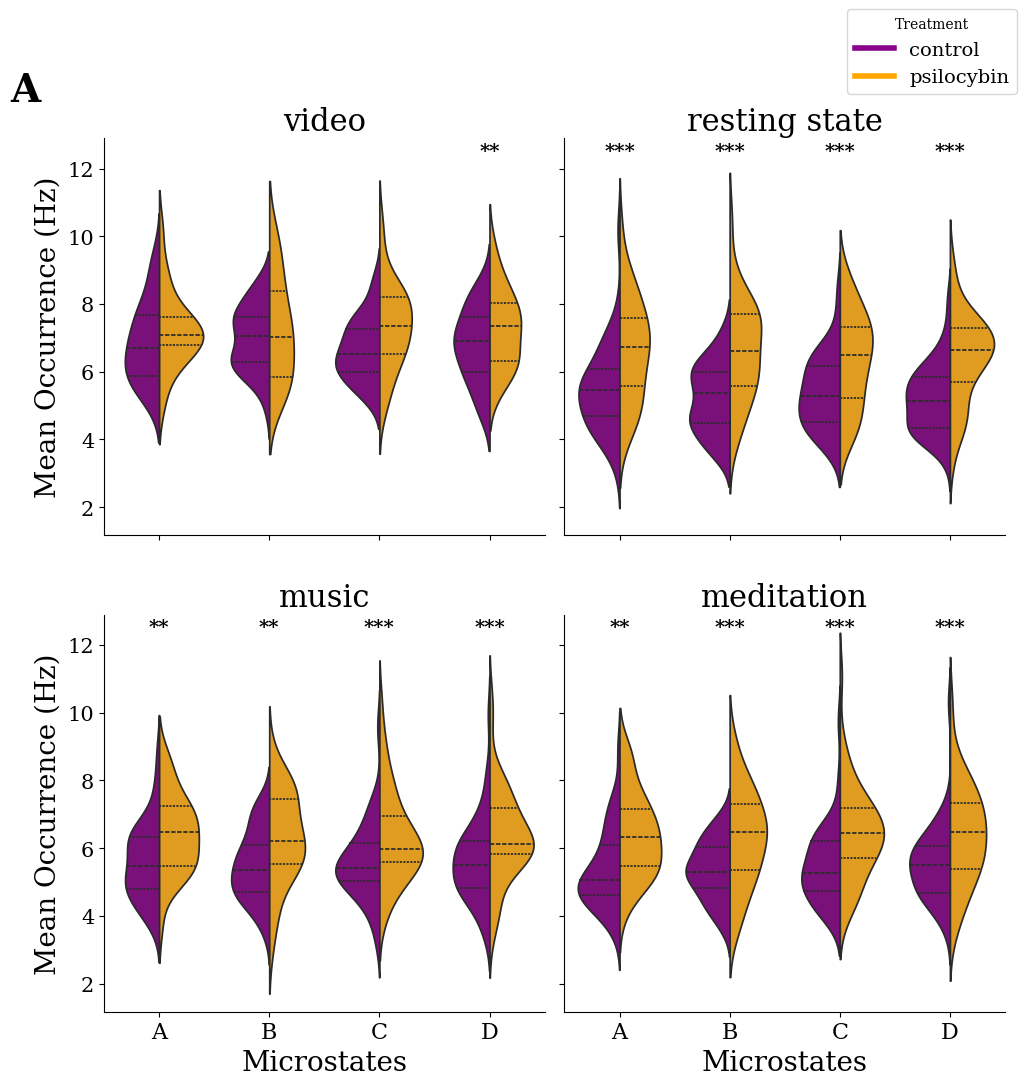

In [ ]:
# Mean Occurrence

occurrence_df = all_datasets[['Condition', 'psi/ctrl', 'MeanOccurrence_A', 'MeanOccurrence_B', 'MeanOccurrence_C', 'MeanOccurrence_D']]
occurrence_melted = pd.melt(occurrence_df, id_vars=['Condition', 'psi/ctrl'],
                           value_vars=['MeanOccurrence_A', 'MeanOccurrence_B', 'MeanOccurrence_C', 'MeanOccurrence_D'],
                           var_name='Occurrence_Type', value_name='Occurrence')

g = sns.catplot(x='Occurrence_Type', y='Occurrence', hue='psi/ctrl', col='Condition',
                data=occurrence_melted, kind='violin', split=True, inner='quart',
                col_wrap=2, height=5, sharey=True,legend=None)
g.set_titles(row_template = '{row_name}', col_template = '{col_name}',fontsize=16)
g.set_axis_labels("Microstates", "Mean Occurrence (Hz)",fontsize=20)

g.set_xticklabels(['A', 'B', 'C', 'D'],fontsize=16)


g.set_titles(row_template = '{row_name}', col_template = '{col_name}',fontsize=68)
g.set_axis_labels("Microstates", "Mean Occurrence (Hz)",fontsize=20)

g.set_xticklabels(['A', 'B', 'C', 'D'],fontsize=16)

sns.despine()
plt.tight_layout()

# Manually create legend elements
legend_elements = [
    mlines.Line2D([0], [0], color=sns.color_palette()[0], lw=4, label='control'),
    mlines.Line2D([0], [0], color=sns.color_palette()[1], lw=4, label='psilocybin')
]

# Add a single legend to the entire figure
plt.legend(handles=legend_elements, title='Treatment', loc='upper right', bbox_to_anchor=(1.05, 2.55),fontsize=14)
plt.text(-0.01, 1.02, 'A', transform=plt.gcf().transFigure, fontsize=28, va='top', fontweight='bold')

## Add asterisks
for ax in g.axes.flat:  # Iterate over subplots
    col_name = ax.get_title()  # Get the title of the subplot, which represents the condition

    # Map condition names to labels used in 'final_FDRs'
    condition_mapping = {'resting state': 'RS', 'music': 'MUSIC', 'meditation': 'GM', 'video': 'VIDEO'}
    label_condition = condition_mapping.get(col_name, None)

    if label_condition:
        for _, row in final_FDRs.iterrows():
            column_parts = row['Label'].split('_')
            if len(column_parts) == 3 and column_parts[2] == label_condition and 'Occurrence' in row['Label']:
                # Extract the first two parts of the label
                column_label = '_'.join(column_parts[:2])

                # Find the x-position of the column label
                x_pos = list(occurrence_melted['Occurrence_Type'].unique()).index(column_label)

                # Determine the asterisk symbol based on p-value
                if row['FDR'] < 0.001:
                    asterisk = '***'
                elif row['FDR'] < 0.01:
                    asterisk = '**'
                elif row['FDR'] < 0.05:
                    asterisk = '*'
                else:
                    asterisk = None  # No asterisk if not significant

                # Add the asterisk above the violin plot if significant
                if asterisk:
                    ax.text(x_pos, ax.get_ylim()[1]*0.95, asterisk, ha='center', va='bottom', fontsize=14, fontweight='bold')

g.fig.subplots_adjust(hspace=0.2)

plt.savefig('occurrence_plot.png', dpi=300, bbox_inches='tight')

plt.show()  # Ensure the plot is displayed

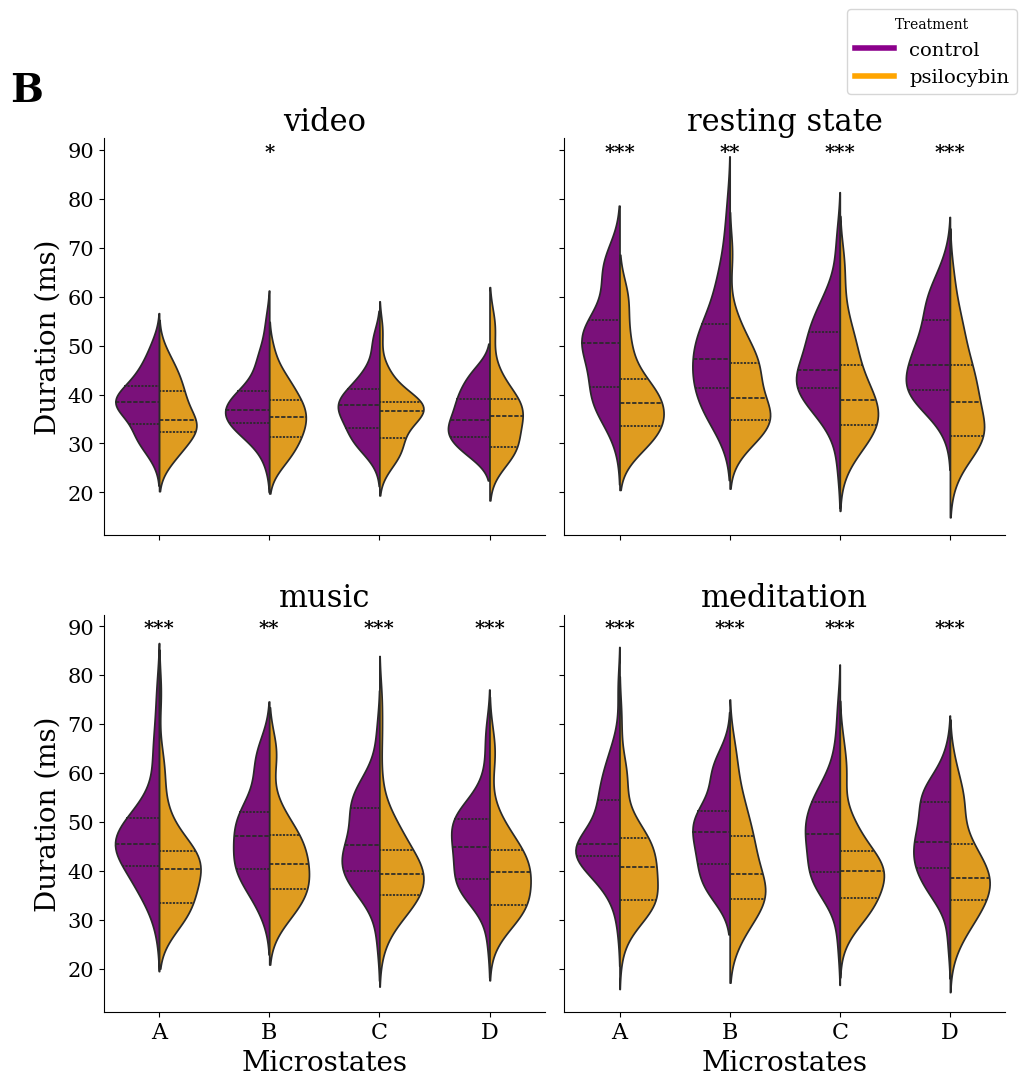

In [ ]:
# Mean Duration
duration_df = all_datasets[['Condition', 'psi/ctrl', 'MeanDuration_A', 'MeanDuration_B', 'MeanDuration_C', 'MeanDuration_D']]
duration_melted = pd.melt(duration_df, id_vars=['Condition', 'psi/ctrl'],
                         value_vars=['MeanDuration_A', 'MeanDuration_B', 'MeanDuration_C', 'MeanDuration_D'],
                         var_name='Duration_Type', value_name='Duration')

duration_melted['Duration'] = duration_melted['Duration'] * 1000

g = sns.catplot(x='Duration_Type', y='Duration', hue='psi/ctrl', col='Condition',
                data=duration_melted, kind='violin', split=True, inner='quart',
                col_wrap=2, height=5, sharey=True,legend = None)

g.set_titles(row_template = '{row_name}', col_template = '{col_name}',fontsize=16)
g.set_axis_labels("Microstates", "Duration (s)",fontsize=20)

g.set_titles(row_template = '{row_name}', col_template = '{col_name}',fontsize=16)


g.set_axis_labels("Microstates", "Duration (ms)",fontsize=20)

g.set_xticklabels(['A', 'B', 'C', 'D'],fontsize = 16)


sns.despine()
plt.tight_layout()

# Manually create legend elements
legend_elements = [
    mlines.Line2D([0], [0], color=sns.color_palette()[0], lw=4, label='control'),
    mlines.Line2D([0], [0], color=sns.color_palette()[1], lw=4, label='psilocybin')
]

# Add a single legend to the entire figure
plt.legend(handles=legend_elements, title='Treatment', loc='upper right', bbox_to_anchor=(1.05, 2.55),fontsize=14)
plt.text(-0.01, 1.02, 'B', transform=plt.gcf().transFigure, fontsize=28, va='top', fontweight='bold')

g.fig.subplots_adjust(hspace=0.2)

for ax in g.axes.flat:  # Iterate over subplots
    col_name = ax.get_title()  # Get the title of the subplot, which represents the condition

    # Map condition names to labels used in 'final_FDRs'
    condition_mapping = {'resting state': 'RS', 'music': 'MUSIC', 'meditation': 'GM', 'video': 'VIDEO'}
    label_condition = condition_mapping.get(col_name, None)

    if label_condition:
        for _, row in final_FDRs.iterrows():
            column_parts = row['Label'].split('_')
            if len(column_parts) == 3 and column_parts[2] == label_condition and 'Duration' in row['Label']:
                # Extract the first two parts of the label
                column_label = '_'.join(column_parts[:2])

                # Find the x-position of the column label
                x_pos = list(duration_melted['Duration_Type'].unique()).index(column_label)

                # Determine the asterisk symbol based on p-value
                if row['FDR'] < 0.001:
                    asterisk = '***'
                elif row['FDR'] < 0.01:
                    asterisk = '**'
                elif row['FDR'] < 0.05:
                    asterisk = '*'
                else:
                    asterisk = None  # No asterisk if not significant

                # Add the asterisk above the violin plot if significant
                if asterisk:
                    ax.text(x_pos, ax.get_ylim()[1]*0.95, asterisk, ha='center', va='bottom', fontsize=14, fontweight='bold')


plt.savefig('duration_plot.png', dpi=300, bbox_inches='tight')


plt.show()  # Ensure the plot is displayed



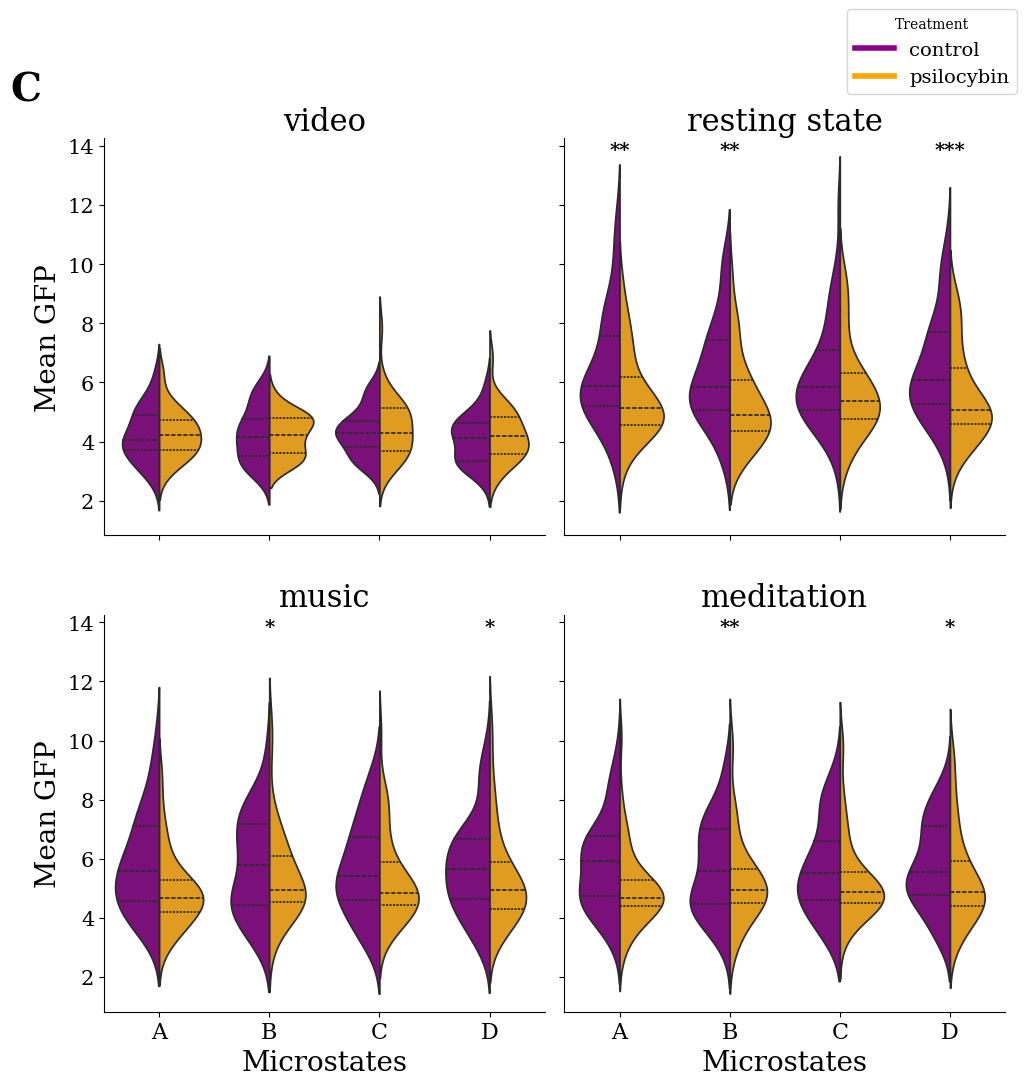

In [ ]:
# Mean GFP


gfp_df = all_datasets[['Condition', 'psi/ctrl', 'MeanGFP_A', 'MeanGFP_B', 'MeanGFP_C', 'MeanGFP_D']]
gfp_melted = pd.melt(gfp_df, id_vars=['Condition', 'psi/ctrl'],
                     value_vars=['MeanGFP_A', 'MeanGFP_B', 'MeanGFP_C', 'MeanGFP_D'],
                     var_name='GFP_Type', value_name='GFP')

g = sns.catplot(x='GFP_Type', y='GFP', hue='psi/ctrl', col='Condition',
                data=gfp_melted, kind='violin', split=True, inner='quart',
                col_wrap=2, height=5, sharey=True,legend = False)

g.set_xticklabels(['A', 'B', 'C', 'D'],fontsize=16)

g.set_titles(row_template = '{row_name}', col_template = '{col_name}',fontsize = 16)
g.set_axis_labels("Microstates", "Mean GFP",fontsize=20)



g.set_titles(row_template = '{row_name}', col_template = '{col_name}',fontsize = 16)
g.set_axis_labels("Microstates", "Mean GFP",fontsize=20)


g.set_xticklabels(['A', 'B', 'C', 'D'],fontsize=16)

sns.despine()
plt.tight_layout()

# Manually create legend elements
legend_elements = [
    mlines.Line2D([0], [0], color=sns.color_palette()[0], lw=4, label='control'),
    mlines.Line2D([0], [0], color=sns.color_palette()[1], lw=4, label='psilocybin')
]

# Add a single legend to the entire figure
plt.legend(handles=legend_elements, title='Treatment', loc='upper right', bbox_to_anchor=(1.05, 2.55),fontsize=14)
plt.text(-0.01, 1.02, 'C', transform=plt.gcf().transFigure, fontsize=28, va='top', fontweight='bold')

g.fig.subplots_adjust(hspace=0.2)

for ax in g.axes.flat:  # Iterate over subplots
    col_name = ax.get_title()  # Get the title of the subplot, which represents the condition

    # Map condition names to labels used in 'final_FDRs'
    condition_mapping = {'resting state': 'RS', 'music': 'MUSIC', 'meditation': 'GM', 'video': 'VIDEO'}
    label_condition = condition_mapping.get(col_name, None)

    if label_condition:
        for _, row in final_FDRs.iterrows():
            column_parts = row['Label'].split('_')
            if len(column_parts) == 3 and column_parts[2] == label_condition and 'GFP' in row['Label']:
                # Extract the first two parts of the label
                column_label = '_'.join(column_parts[:2])

                # Find the x-position of the column label
                x_pos = list(gfp_melted['GFP_Type'].unique()).index(column_label)

                # Determine the asterisk symbol based on p-value
                if row['FDR'] < 0.001:
                    asterisk = '***'
                elif row['FDR'] < 0.01:
                    asterisk = '**'
                elif row['FDR'] < 0.05:
                    asterisk = '*'
                else:
                    asterisk = None  # No asterisk if not significant

                # Add the asterisk above the violin plot if significant
                if asterisk:
                    ax.text(x_pos, ax.get_ylim()[1]*0.95, asterisk, ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.savefig('gfp_plot.png', dpi=300, bbox_inches='tight')

plt.show()  # Ensure the plot is displayed

In [ ]:
# Open the images
image1 = Image.open('occurrence_plot.png')
image2 = Image.open('duration_plot.png')
image3 = Image.open('gfp_plot.png')

# Set the desired spacing between images
spacing = 50  # Adjust as needed

# Calculate dimensions for the combined image
total_width = image1.width + image2.width + spacing
total_height = max(image1.height, image2.height) + image3.height + spacing

# Create a new blank image for the combined plot
new_image = Image.new('RGB', (total_width, total_height), color='white')

# Paste the top row images
new_image.paste(image1, (0, 0))
new_image.paste(image2, (image1.width + spacing, 0))

# Calculate the x-coordinate to center image3
x_offset_bottom = (total_width - image3.width) // 2

# Paste the bottom image
new_image.paste(image3, (x_offset_bottom, max(image1.height, image2.height) + spacing))

# Save the combined image
new_image.save('combined_plots.png')